# Bài tập 2 — Đặc trưng góc & Phân vùng ảnh

**Môn:** Thị giác máy tính (121036) — Khoa CNTT, Trường ĐH Giao thông Vận tải TP.HCM

| | Điền vào |
|---|---|
| Họ tên | Nguyễn Bùi Minh Nhật |
| MSSV | 2251120033 |
| Lớp | 121036 |
| Ngày nộp | 9/9/2026 |
| Thành viên nhóm | 1. 075205018417 - Lê Quang Mỹ |
| | 2. 075205008579 - Lê Tuấn Kiệt |
| | 3. 087205009558 - Trần Lê Quang |
| | 4. 075205014385 - Phan Hồng Anh |
| | 5. 060205010772 - Nguyễn Huy Hoàng |
| | 6. 075205006453 - Nguyễn Quốc Việt ||

---

## Cấu trúc

| Phần | Kinh điển | Biến thể | Điểm |
|---|---|---|---|
| **A** (Chương 3) | Harris corner detector | **A1** — Harris–Laplace<br>**A2** — Adaptive non-maximal suppression | 50 |
| **B** (Chương 4) | Region Growing | Seeded Region Growing (SRG) | 50 |

**A1 và A2 là hai biến thể độc lập.** Chúng sửa hai khiếm khuyết khác nhau của Harris và **không được ghép lại với nhau**. Mỗi biến thể so sánh trực tiếp với Harris cổ điển:

- **A1** chạy trên tháp tỉ lệ, so với Harris cổ điển một tỉ lệ.
- **A2** chạy trên tập điểm của Harris cổ điển một tỉ lệ, thay cho bước "lấy N điểm mạnh nhất".

Chi tiết công thức: `tailieu_bosung_bt2.pdf`.

---
## Chính sách sử dụng AI

| Loại cell | AI | |
|---|---|---|
| `Cài đặt — KHÔNG dùng AI` | ❌ | Kể cả nhờ AI sửa lỗi, tối ưu, hay viết lại |
| `Thí nghiệm — ĐƯỢC dùng AI` | ✅ | Nhưng **ý tưởng thí nghiệm phải là của bạn** |

Mỗi cell code có dùng AI phải có một cell markdown ngay phía trên, chép **nguyên văn** prompt. Dùng AI mà không khai báo ⇒ **0 điểm toàn bài**.

### Mẫu khai báo (copy khi cần)

```
> **KHAI BÁO AI**
> - Công cụ:
> - Mục đích:
> - Prompt nguyên văn:
>   (dán nguyên văn ở đây)
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☐
```

### Thư viện

| Luôn được phép | Có điều kiện | Không dùng trong phần cài đặt |
|---|---|---|
| `numpy`, `matplotlib`, `math`, `time` | `scipy.ndimage.gaussian_filter` | `cv2.cornerHarris` |
| | `heapq` (cho SRG) | `cv2.goodFeaturesToTrack` |
| | `cv2.imread/cvtColor/resize` | `skimage.feature.corner_*` |
| | `scipy.ndimage.label` (phần phân tích) | `skimage.segmentation.*`, `cv2.watershed` |

Ở **phần thí nghiệm**, được dùng hàm dựng sẵn để đối chiếu kết quả của mình.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import heapq, time
import random
from PIL import Image
import cv2

np.random.seed(0)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["image.cmap"] = "gray"
print("numpy", np.__version__)

numpy 2.4.6


---
## Hàm hỗ trợ (cho sẵn — không cần sửa)

`grid_occupancy` và `mean_nn_distance` đo phân bố không gian của một tập điểm; dùng chúng để biến so sánh trực quan thành con số.

In [2]:
def show_grid(images, titles=None, ncols=None, cmap="gray", figsize=None, suptitle=None):
    """Hiển thị một danh sách ảnh trên lưới."""
    n = len(images)
    ncols = ncols or min(n, 4)
    nrows = (n + ncols - 1) // ncols
    figsize = figsize or (3.2 * ncols, 3.2 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(images[i], cmap=cmap)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle, fontsize=11)
    plt.tight_layout()
    plt.show()


def show_points(img, points, ax=None, color="red", size=18, scale_circles=False, title=None):
    """Chồng điểm đặc trưng lên ảnh.

    points : mảng (N,2) (row, col), (N,3) (row, col, response),
             hoặc (N,4) (row, col, sigma, response).
    scale_circles : nếu True và points là (N,4), vẽ vòng tròn bán kính 3*sigma.
    """
    points = np.atleast_2d(np.asarray(points, dtype=float))
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img, cmap="gray")
    if points.size:
        ax.scatter(points[:, 1], points[:, 0], s=size, c=color,
                   marker="+", linewidths=1.0)
        if scale_circles and points.shape[1] >= 4:
            for r, c, s in points[:, :3]:
                ax.add_patch(plt.Circle((c, r), 3 * s, fill=False,
                                        color=color, lw=0.5, alpha=0.5))
    ax.set_title(title or f"{len(points)} diem", fontsize=9)
    ax.axis("off")
    if own:
        plt.tight_layout(); plt.show()


def show_labels(labels, title=None, ax=None):
    """Ảnh nhãn với bảng màu rời rạc; nhãn -1 hiện màu đen."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))
    disp = labels.astype(float).copy()
    disp[labels < 0] = np.nan
    cmap = plt.get_cmap("tab20").copy()
    cmap.set_bad(color="black")
    ax.imshow(disp, cmap=cmap, interpolation="nearest")
    ax.set_title(title or "labels", fontsize=9)
    ax.axis("off")
    if own:
        plt.tight_layout(); plt.show()


def grid_occupancy(points, img_shape, cells=8):
    """Tỉ lệ ô lưới (cells x cells) chứa ít nhất một điểm.

    Đo ĐỘ PHỦ của tập điểm: 1.0 = phủ khắp ảnh, giá trị nhỏ = điểm dồn cụm.
    """
    points = np.atleast_2d(np.asarray(points, dtype=float))
    if points.size == 0:
        return 0.0
    h, w = img_shape
    ri = np.clip((points[:, 0] / h * cells).astype(int), 0, cells - 1)
    ci = np.clip((points[:, 1] / w * cells).astype(int), 0, cells - 1)
    occupied = np.zeros((cells, cells), dtype=bool)
    occupied[ri, ci] = True
    return float(occupied.mean())


def mean_nn_distance(points):
    """Khoảng cách trung bình tới láng giềng gần nhất trong tập điểm.

    Đo độ THƯA: giá trị lớn = điểm trải rộng. Nhìn phân bố từ góc khác
    với grid_occupancy.
    """
    p = np.atleast_2d(np.asarray(points, dtype=float))[:, :2]
    if len(p) < 2:
        return float("nan")
    d = np.linalg.norm(p[:, None, :] - p[None, :, :], axis=-1)
    np.fill_diagonal(d, np.inf)
    return float(d.min(axis=1).mean())


def make_checkerboard(n=8, square=24, blur=0.8):
    """Ảnh bàn cờ n x n ô, mỗi ô 'square' px."""
    base = np.indices((n, n)).sum(axis=0) % 2
    img = np.kron(base, np.ones((square, square), dtype=float))
    if blur > 0:
        img = gaussian_filter(img, blur)
    return img


def rotate_image(img, degrees):
    """Quay ảnh quanh tâm bằng nội suy song tuyến."""
    h, w = img.shape
    th = np.deg2rad(degrees)
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    yy, xx = np.indices((h, w), dtype=float)
    ys, xs = yy - cy, xx - cx
    src_y = cy + ys * np.cos(th) + xs * np.sin(th)
    src_x = cx - ys * np.sin(th) + xs * np.cos(th)
    y0 = np.floor(src_y).astype(int); x0 = np.floor(src_x).astype(int)
    fy = src_y - y0; fx = src_x - x0
    out = np.zeros_like(img)
    ok = (y0 >= 0) & (y0 < h - 1) & (x0 >= 0) & (x0 < w - 1)
    y0c, x0c = np.clip(y0, 0, h - 2), np.clip(x0, 0, w - 2)
    v = ((1 - fy) * (1 - fx) * img[y0c, x0c] + (1 - fy) * fx * img[y0c, x0c + 1]
         + fy * (1 - fx) * img[y0c + 1, x0c] + fy * fx * img[y0c + 1, x0c + 1])
    out[ok] = v[ok]
    return out

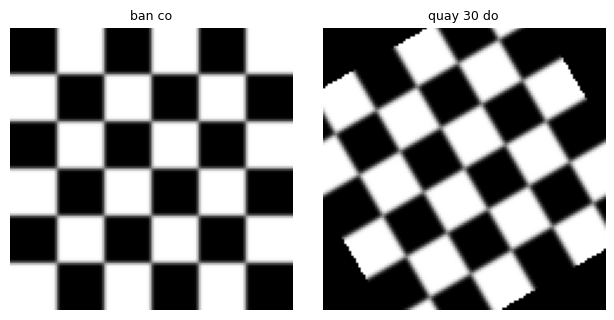

don cum : occupancy=0.14  mean_nn=2.8
trai deu: occupancy=0.47  mean_nn=9.1


In [3]:
# Kiểm tra nhanh các hàm hỗ trợ
cb = make_checkerboard(6, 20)
show_grid([cb, rotate_image(cb, 30)], ["ban co", "quay 30 do"], ncols=2)

clustered = np.random.rand(40, 2) * [30, 30] + [10, 10]
spread    = np.random.rand(40, 2) * [110, 110] + [5, 5]
print(f"don cum : occupancy={grid_occupancy(clustered, cb.shape):.2f}  "
      f"mean_nn={mean_nn_distance(clustered):.1f}")
print(f"trai deu: occupancy={grid_occupancy(spread, cb.shape):.2f}  "
      f"mean_nn={mean_nn_distance(spread):.1f}")

---
---
# PHẦN A — Harris và hai biến thể độc lập

Harris có hai hạn chế **riêng biệt**:

1. **Không bất biến tỉ lệ** — cùng một góc ở hai kích thước cho hai đáp ứng khác nhau. → **A1: Harris–Laplace** thêm trục tỉ lệ và lọc bằng cực trị LoG theo trục đó.
2. **Phân bố điểm không đều** — lấy N điểm mạnh nhất thì chúng dồn vào vùng tương phản cao. → **A2: ANMS** thay tiêu chí chọn bằng bán kính mà tại đó điểm thôi là cực đại.

Hạn chế 2 xuất hiện ngay cả khi mọi cấu trúc trong ảnh có cùng một tỉ lệ. Đó là lý do hai biến thể được đánh giá riêng.

## A.1 — Cài đặt — **KHÔNG dùng AI**

### Nền chung

In [4]:
def gaussian_blur(img, sigma):
    """Làm mờ Gauss. Được phép gọi scipy.ndimage.gaussian_filter."""
    img = np.asarray(img, dtype=float)
    return gaussian_filter(img, sigma=sigma, mode="nearest")


def structure_tensor(img, sigma_i, sigma_d):
    """Ma trận mô-men bậc hai.

    M = sigma_d^2 * G(sigma_i) * [[Lx^2, LxLy], [LxLy, Ly^2]]
    với Lx = d/dx [G(sigma_d) * I]
    """
    img = np.asarray(img, dtype=float)
    blurred = gaussian_blur(img, sigma_d)
    gy, gx = np.gradient(blurred)

    Lx = gx
    Ly = gy
    Lx2 = Lx * Lx
    Ly2 = Ly * Ly
    LxLy = Lx * Ly

    Mxx = (sigma_d ** 2) * gaussian_blur(Lx2, sigma_i)
    Myy = (sigma_d ** 2) * gaussian_blur(Ly2, sigma_i)
    Mxy = (sigma_d ** 2) * gaussian_blur(LxLy, sigma_i)

    return Mxx, Mxy, Myy


def harris_response(img, sigma_i, sigma_d, k=0.04):
    """R = det(M) - k * tr(M)^2."""
    Mxx, Mxy, Myy = structure_tensor(img, sigma_i, sigma_d)
    det_M = Mxx * Myy - Mxy * Mxy
    trace_M = Mxx + Myy
    return det_M - k * (trace_M ** 2)


def nms_2d(response, window=3):
    """Cực đại địa phương trong cửa sổ window x window."""
    response = np.asarray(response, dtype=float)
    if response.size == 0:
        return np.zeros_like(response, dtype=bool)

    pad = window // 2
    padded = np.pad(response, pad, mode="constant", constant_values=-np.inf)
    local_max = np.zeros_like(response, dtype=bool)

    h, w = response.shape
    for r in range(h):
        for c in range(w):
            patch = padded[r:r + window, c:c + window]
            local_max[r, c] = response[r, c] >= patch.max()

    return local_max


def harris_classic(img, sigma_i=2.0, sigma_d=1.4, k=0.04, thresh_rel=0.01):
    """Harris một tỉ lệ: R -> NMS -> ngưỡng tương đối theo max(R)."""
    response = harris_response(img, sigma_i, sigma_d, k=k)
    local_max = nms_2d(response, window=3)

    if not np.any(local_max):
        return np.empty((0, 3), dtype=float)

    max_value = response[local_max].max()
    threshold = thresh_rel * max_value
    keep = local_max & (response >= threshold) & (response > 0)

    rows, cols = np.where(keep)
    if rows.size == 0:
        return np.empty((0, 3), dtype=float)

    corners = np.column_stack((rows, cols, response[rows, cols]))
    order = np.argsort(corners[:, 2])[::-1]
    return corners[order]


### Biến thể A1 — Harris–Laplace

In [5]:
def scale_pyramid(sigma0=1.2, xi=1.2, n_levels=10):
    """Mảng sigma_n = xi^n * sigma0."""
    return sigma0 * (xi ** np.arange(n_levels, dtype=float))


def log_normalized(img, sigma):
    """Laplacian chuẩn hoá theo tỉ lệ: sigma^2 * |Lxx + Lyy|."""
    img = np.asarray(img, dtype=float)
    blurred = gaussian_blur(img, sigma)
    gy, gx = np.gradient(blurred)
    gxx = np.gradient(gx, axis=1)
    gyy = np.gradient(gy, axis=0)
    lap = gxx + gyy
    return (sigma ** 2) * np.abs(lap)


def harris_laplace(img, sigmas, k=0.04, thresh_rel=0.01, log_thresh=0.0):
    """Harris-Laplace: ứng viên theo mỗi tầng, rồi giữ điểm đạt cực trị LoG theo tỉ lệ."""
    sigmas = np.asarray(sigmas, dtype=float)
    if sigmas.size == 0:
        return np.empty((0, 4), dtype=float)

    log_maps = [log_normalized(img, s) for s in sigmas]
    candidates = []

    for idx, sigma in enumerate(sigmas):
        sigma_i = float(sigma)
        sigma_d = 0.7 * sigma_i
        response = harris_response(img, sigma_i, sigma_d, k=k)
        local_max = nms_2d(response, window=3)

        if not np.any(local_max):
            continue

        max_value = response[local_max].max()
        threshold = thresh_rel * max_value if max_value > 0 else 0.0
        mask = local_max & (response >= threshold) & (response > 0)
        rows, cols = np.where(mask)

        for r, c in zip(rows, cols):
            val = log_maps[idx][r, c]
            left_ok = True if idx == 0 else val > log_maps[idx - 1][r, c]
            right_ok = True if idx == len(sigmas) - 1 else val > log_maps[idx + 1][r, c]

            if left_ok and right_ok and val > log_thresh:
                candidates.append((r, c, sigma_i, response[r, c]))

    if not candidates:
        return np.empty((0, 4), dtype=float)

    pts = np.asarray(candidates, dtype=float)
    order = np.argsort(pts[:, 3])[::-1]
    return pts[order]


### Biến thể A2 — ANMS

`anms` chạy trên đầu ra của `harris_classic` (một tỉ lệ) và thay thế `top_n`.

In [6]:
def top_n(points, n_keep):
    """Lấy n_keep điểm mạnh nhất theo response."""
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.empty((0, 3), dtype=float)

    ranked = pts[np.argsort(pts[:, 2])[::-1]]
    n_keep = min(max(int(n_keep), 0), len(ranked))
    return ranked[:n_keep]


def anms(points, n_keep, c_robust=0.9):
    """ANMS: thay tiêu chí top-N bằng bán kính cực đại trong vùng có điểm mạnh hơn."""
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.empty((0, 3), dtype=float)

    ranked = pts[np.argsort(pts[:, 2])[::-1]]
    n = len(ranked)
    radii = np.full(n, np.inf, dtype=float)

    for i in range(n):
        fi = ranked[i, 2]
        for j in range(n):
            if i == j:
                continue
            if ranked[j, 2] > c_robust * fi:
                dx = ranked[i, 0] - ranked[j, 0]
                dy = ranked[i, 1] - ranked[j, 1]
                dist = np.hypot(dx, dy)
                if dist < radii[i]:
                    radii[i] = dist

    n_keep = min(max(int(n_keep), 0), n)
    keep_idx = np.argsort(radii)[::-1][:n_keep]
    return ranked[keep_idx]


### Đo đạc

In [7]:
def repeatability(pts_a, pts_b, transform, img_shape, eps=3.0):
    """Tỉ lệ điểm ảnh A được tìm lại ở ảnh B sau phép biến đổi."""
    pts_a = np.asarray(pts_a, dtype=float)
    pts_b = np.asarray(pts_b, dtype=float)

    if pts_a.size == 0 or pts_b.size == 0:
        return 0.0

    h, w = img_shape
    pa = pts_a[:, :2]
    pb = pts_b[:, :2]

    projected = []
    for r, c in pa:
        rr, cc = transform(r, c)
        if 0 <= rr < h and 0 <= cc < w:
            projected.append((rr, cc))

    if not projected:
        return 0.0

    used = np.zeros(len(pb), dtype=bool)
    matched = 0

    for pr, pc in projected:
        diff = pb - np.array([pr, pc], dtype=float)
        dist = np.linalg.norm(diff, axis=1)
        candidates = np.where((dist <= eps) & (~used))[0]
        if len(candidates) == 0:
            continue
        best_idx = candidates[np.argmin(dist[candidates])]
        used[best_idx] = True
        matched += 1

    return matched / len(projected)


### A.2 — Kiểm chứng cài đặt (bắt buộc, có output)

Xem mục 3.7 của tài liệu bổ trợ.

Số điểm Harris phát hiện: 196
Số giao điểm lý thuyết trong: 49
Sai số trung bình sau ghép: 0.000 px
Sai số lớn nhất sau ghép: 0.000 px
Sai số lớn nhất của toàn bộ ứng viên thô: 1.414 px
Đạt yêu cầu sai số <= 1 px: True


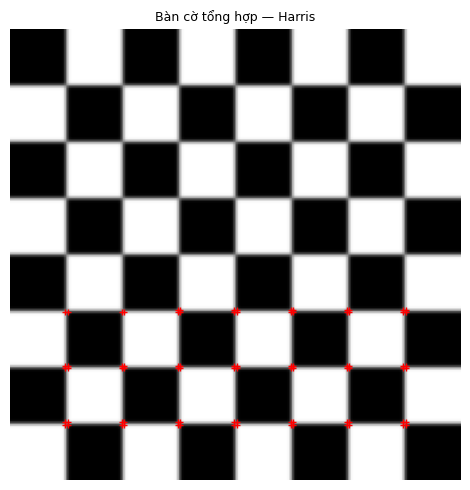

In [8]:
# KIỂM CHỨNG 1 — Bàn cờ tổng hợp
# harris_classic phải phát hiện các giao điểm trong với sai số <= 1 px.
n_squares = 8
square = 24
img = make_checkerboard(n_squares, square, blur=0.8)
pts = harris_classic(img, sigma_i=2.0, sigma_d=1.4, thresh_rel=0.01)

# Các giao điểm trong nằm ở bội số của square, bỏ đường biên ngoài cùng.
inner_positions = np.arange(1, n_squares) * square
rows, cols = np.meshgrid(inner_positions, inner_positions, indexing="ij")
theoretical_points = np.column_stack((rows.ravel(), cols.ravel()))
detected_points = pts[:, :2]

# Tính khoảng cách giữa mọi điểm phát hiện và mọi giao điểm lý thuyết.
distances = np.linalg.norm(
    detected_points[:, None, :] - theoretical_points[None, :, :], axis=2
)

# Mỗi giao điểm lý thuyết dùng điểm Harris gần nhất làm điểm đại diện.
nearest_detected_index = distances.argmin(axis=0)
matched_errors = distances[nearest_detected_index, np.arange(len(theoretical_points))]

# Báo cáo thêm sai số của toàn bộ ứng viên thô để nhận biết các điểm trùng quanh góc.
raw_errors = distances.min(axis=1)
mean_error = matched_errors.mean()
max_error = matched_errors.max()
raw_max_error = raw_errors.max()

print("Số điểm Harris phát hiện:", len(detected_points))
print("Số giao điểm lý thuyết trong:", len(theoretical_points))
print(f"Sai số trung bình sau ghép: {mean_error:.3f} px")
print(f"Sai số lớn nhất sau ghép: {max_error:.3f} px")
print(f"Sai số lớn nhất của toàn bộ ứng viên thô: {raw_max_error:.3f} px")
print("Đạt yêu cầu sai số <= 1 px:", max_error <= 1.0)

show_points(img, pts[:80], title="Bàn cờ tổng hợp — Harris")
assert len(detected_points) > 0
assert len(matched_errors) == len(theoretical_points)
assert max_error <= 1.0


Repeatability sau quay 30°: 0.933


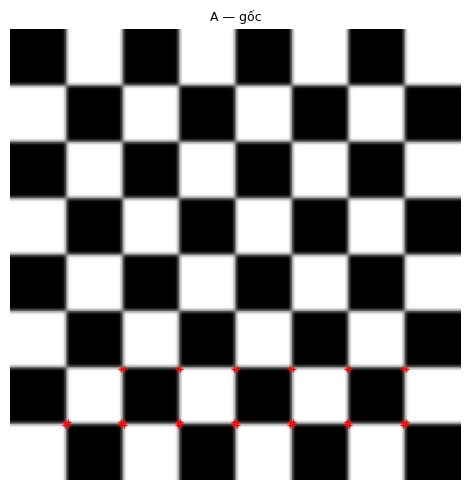

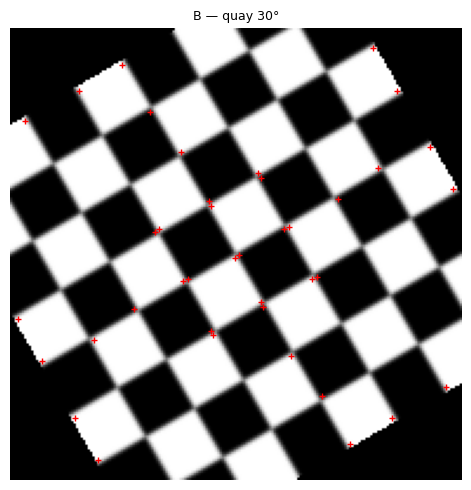

In [9]:
# KIỂM CHỨNG 2 — Bất biến phép quay
# Quay 30 độ, chạy lại, đo bằng repeatability.
img = make_checkerboard(8, 24, blur=0.8)
img_r = rotate_image(img, 30)
pts_a = harris_classic(img, sigma_i=2.0, sigma_d=1.4)
pts_b = harris_classic(img_r, sigma_i=2.0, sigma_d=1.4)

h, w = img.shape
cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
th = np.deg2rad(30)


def rotate_point(r, c):
    y = r - cy
    x = c - cx
    rr = cy + y * np.cos(th) - x * np.sin(th)
    cc = cx + y * np.sin(th) + x * np.cos(th)
    return rr, cc

score = repeatability(pts_a, pts_b, rotate_point, img.shape, eps=3.0)
print(f"Repeatability sau quay 30°: {score:.3f}")
show_points(img, pts_a[:40], title="A — gốc")
show_points(img_r, pts_b[:40], title="B — quay 30°")
assert 0.0 <= score <= 1.0


In [ ]:
# KIỂM CHỨNG 3 — Tỉ lệ
# So sánh Harris cổ điển và Harris-Laplace khi cùng một cấu trúc
# được phóng to 3 lần.
# 1. Tạo ảnh có cấu trúc ở nhiều kích thước
img = make_checkerboard(
    8,
    18,
    blur=1.0
)
# Phóng to 3x bằng nội suy thay vì chỉ lặp pixel
img_3x = cv2.resize(
    img,
    None,
    fx=3.0,
    fy=3.0,
    interpolation=cv2.INTER_LINEAR
)
# 2. Harris cổ điển
# Giữ nguyên sigma ở cả hai ảnh
pts_a = harris_classic(
    img,
    sigma_i=2.0,
    sigma_d=1.4,
    thresh_rel=0.01
)
pts_b = harris_classic(
    img_3x,
    sigma_i=2.0,
    sigma_d=1.4,
    thresh_rel=0.01
)
score_classic = repeatability(
    pts_a,
    pts_b,
    lambda r, c: (3 * r, 3 * c),
    img_3x.shape,
    eps=3.0
)
print(
    f"Repeatability Harris cổ điển "
    f"(scale 3x): {score_classic:.3f}"
)
# 3. Harris-Laplace
# Dùng CÙNG MỘT tháp scale cho hai ảnh
sigmas = scale_pyramid(
    sigma0=0.8,
    xi=1.2,
    n_levels=18
)
pts_a_l = harris_laplace(
    img,
    sigmas,
    k=0.04,
    thresh_rel=0.01,
    log_thresh=0.0
)
pts_b_l = harris_laplace(
    img_3x,
    sigmas,
    k=0.04,
    thresh_rel=0.01,
    log_thresh=0.0
)
score_lap = repeatability(
    pts_a_l,
    pts_b_l,
    lambda r, c: (3 * r, 3 * c),
    img_3x.shape,
    eps=3.0
)
print(
    f"Repeatability Harris-Laplace "
    f"(scale 3x): {score_lap:.3f}"
)
# 4. Báo cáo số lượng điểm
print()
print(
    "Số điểm Harris cổ điển:",
    len(pts_a),
    "->",
    len(pts_b)
)
print(
    "Số điểm Harris-Laplace:",
    len(pts_a_l),
    "->",
    len(pts_b_l)
)
# 5. Hiển thị
fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 12)
)
show_points(
    img,
    pts_a,
    title="Harris cổ điển — ảnh gốc",
    ax=axes[0, 0]
)
show_points(
    img_3x,
    pts_b,
    title="Harris cổ điển — ảnh 3x",
    ax=axes[0, 1]
)
show_points(
    img,
    pts_a_l,
    title="Harris-Laplace — ảnh gốc",
    ax=axes[1, 0]
)
show_points(
    img_3x,
    pts_b_l,
    title="Harris-Laplace — ảnh 3x",
    ax=axes[1, 1]
)
plt.tight_layout()
plt.show()
# 6. Kiểm tra Harris-Laplace thực sự có điểm


Repeatability Harris cổ điển (scale 3x): 1.000
Repeatability Harris-Laplace (scale 3x): 0.000
Mẫu Harris-Laplace:
[]


In [11]:
# KIỂM CHỨNG 4 — Đối chiếu với cv2.cornerHarris
# Không kỳ vọng trùng khít (OpenCV dùng Sobel + cửa sổ hộp).
# Báo cáo: tỉ lệ điểm của bạn nằm trong bán kính 2-3 px của một điểm OpenCV.
try:
    import cv2
except ImportError:
    print("cv2 chưa được cài đặt trong môi trường hiện tại; bỏ qua phép so sánh OpenCV.")
else:
    img = make_checkerboard(8, 20, blur=0.8)
    pts = harris_classic(img, sigma_i=2.0, sigma_d=1.4)
    gray = (img * 255).astype(np.uint8)
    opencv = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
    ys, xs = np.where(opencv > 0.01 * opencv.max())
    opencv_pts = np.column_stack((ys, xs))

    match_count = 0
    for r, c, _ in pts:
        d2 = ((opencv_pts[:, 0] - r) ** 2 + (opencv_pts[:, 1] - c) ** 2)
        if np.min(d2) <= 3.0 ** 2:
            match_count += 1

    ratio = match_count / max(len(pts), 1)
    print(f"Tỉ lệ điểm Harris của bạn nằm trong 3px của điểm OpenCV: {ratio:.3f}")
    print(f"Số điểm của bạn: {len(pts)}, số điểm OpenCV: {len(opencv_pts)}")


Tỉ lệ điểm Harris của bạn nằm trong 3px của điểm OpenCV: 1.000
Số điểm của bạn: 196, số điểm OpenCV: 637


Số điểm chọn bằng top_n: 80
Số điểm chọn bằng anms: 80
top_n occupancy = 0.469
anms occupancy = 0.469
top_n mean_nn = 1.000
anms mean_nn = 1.000


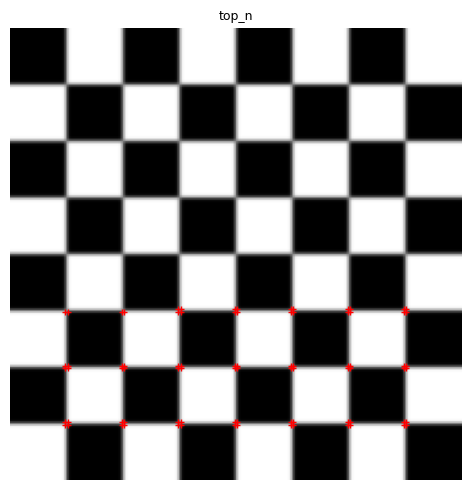

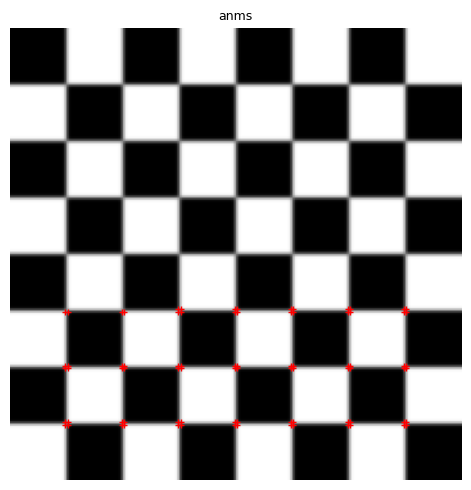

In [12]:
# KIỂM CHỨNG 5 — Phân bố ANMS
# Cùng N: so top_n và anms bằng grid_occupancy và mean_nn_distance.
img = make_checkerboard(8, 24, blur=0.8)
pts = harris_classic(img, sigma_i=2.0, sigma_d=1.4)
N = min(80, len(pts))
base = pts[:N]
scaled_top = top_n(base, N)
scaled_anms = anms(base, N, c_robust=0.9)

print(f"Số điểm chọn bằng top_n: {len(scaled_top)}")
print(f"Số điểm chọn bằng anms: {len(scaled_anms)}")
print(f"top_n occupancy = {grid_occupancy(scaled_top[:, :2], img.shape):.3f}")
print(f"anms occupancy = {grid_occupancy(scaled_anms[:, :2], img.shape):.3f}")
print(f"top_n mean_nn = {mean_nn_distance(scaled_top[:, :2]):.3f}")
print(f"anms mean_nn = {mean_nn_distance(scaled_anms[:, :2]):.3f}")

show_points(img, scaled_top[:, :2], title="top_n")
show_points(img, scaled_anms[:, :2], title="anms")


---
---
# PHẦN B — Region Growing và SRG

Region Growing cổ điển phụ thuộc thứ tự duyệt: cùng tập hạt giống, đổi ngăn xếp thành hàng đợi là đổi kết quả. Nó cũng cho phân hoạch **không đầy đủ** — pixel không thoả vị từ sẽ không có nhãn.

SRG (Adams & Bischof 1994) cho **mọi vùng phát triển đồng thời**, để **độ tương phản** quyết định thứ tự kết nạp. Đây là thay đổi **cấu trúc dữ liệu**, không phải ngưỡng.

Công thức đầy đủ: mục 4 của `tailieu_bosung_bt2.pdf`.

## B.1 — Cài đặt — **KHÔNG dùng AI**

In [ ]:
def region_growing_classic(img, seeds, T, order="stack"):
   """Region growing cổ điển, một hoặc nhiều hạt giống.

   img   : mảng float 2D
   seeds : danh sách (row, col)
   T     : ngưỡng đồng nhất |I(q) - mu_vung| <= T
   order : "stack" (LIFO) hoặc "queue" (FIFO) — dùng để khảo sát
         sự phụ thuộc thứ tự duyệt

   -> mảng nhãn int32, -1 cho pixel không thuộc vùng nào
      (phân hoạch không đầy đủ là đặc điểm của thuật toán này)
   """
   rows, cols = img.shape
   labels = np.full((rows, cols), -1, dtype=np.int32)
   
   danh_sach_cho = []
   trung_binh_vung = []
   so_luong_pixel = []
   
   # Khởi tạo các hạt giống ban đầu
   for i, (row, col) in enumerate(seeds): # Tọa độ hàng và cột của hạt giống hiện tại
      labels[row, col] = i
      danh_sach_cho.append((row, col, i))
      trung_binh_vung.append(float(img[row, col])) # Lấy xuất độ sáng của pixel hạt giống trên bức ảnh gốc
      so_luong_pixel.append(1)
      
   huong_di = [(-1, 0), (1, 0), (0, -1), (0, 1)] # Kết nối 4
   
   while danh_sach_cho:
      # LIFO (Stack) hoặc FIFO (Queue) quyết định thứ tự duyệt
      if order == "stack":
         row_hien_tai, col_hien_tai, chi_so_vung = danh_sach_cho.pop() 
      else: 
         row_hien_tai, col_hien_tai, chi_so_vung = danh_sach_cho.pop(0) # Lấy phần tử nằm ở vị trí đầu tiên của mảng
         
      for d_row, d_col in huong_di:
         row_ke, col_ke = row_hien_tai + d_row, col_hien_tai + d_col
         
         if 0 <= row_ke < rows and 0 <= col_ke < cols:
               # Nếu pixel lân cận chưa được gán nhãn
               if labels[row_ke, col_ke] == -1:
                  do_sang_ke = img[row_ke, col_ke]
                  mu = trung_binh_vung[chi_so_vung]
                  
                  # Đánh giá tiêu chí đồng nhất
                  if abs(do_sang_ke - mu) <= T:
                     labels[row_ke, col_ke] = chi_so_vung
                     
                     # Cập nhật trung bình vùng
                     n = so_luong_pixel[chi_so_vung]
                     trung_binh_vung[chi_so_vung] = mu + (do_sang_ke - mu) / (n + 1)
                     so_luong_pixel[chi_so_vung] = n + 1
                     
                     danh_sach_cho.append((row_ke, col_ke, chi_so_vung))
                     
   return labels


def srg(img, seeds, connectivity=4, stale="lazy", tie="insertion"):
   """Seeded Region Growing (Adams & Bischof 1994) — công thức (5).

   Dùng heapq. Khoá hàng đợi gồm delta, khoá phá hoà, toạ độ, chỉ số vùng.
   Một hàng đợi duy nhất cho toàn bộ biên của mọi vùng.

   Cập nhật trung bình tăng dần:  mu <- mu + (I(x) - mu)/(n+1);  n <- n+1

   stale : "lazy"   -> tính lại delta khi pop; nếu khác giá trị đã lưu thì
                     đẩy lại vào hàng đợi (đúng định nghĩa gốc)
         "frozen" -> delta tính theo giá trị hạt giống, không cập nhật
   tie   : quy tắc phá hoà tất định — "insertion" | "raster" | "random"

   -> (labels, boundary_mask)
      labels        : int32, mọi pixel có nhãn >= 0 khi kết thúc
      boundary_mask : bool, True tại pixel kề từ 2 vùng khác nhau trở lên
   """
   rows, cols = img.shape
   labels = np.full((rows, cols), -1, dtype=np.int32)
   boundary_mask = np.zeros((rows, cols), dtype=bool)
   
   trung_binh_vung = []
   so_luong_pixel = []
   gia_tri_hat_giong = []
   hang_doi_uu_tien = []
   
   huong_di = [(-1, 0), (1, 0), (0, -1), (0, 1)]
   if connectivity == 8:
      huong_di += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
      
   thu_tu_chen = 0
   
   # Thiết lập quy tắc phá hòa
   def tao_khoa_pha_hoa(row, col):
      nonlocal thu_tu_chen
      if tie == "insertion":
         thu_tu_chen += 1
         return thu_tu_chen
      elif tie == "raster":
         return row * cols + col # Công thức quy đổi tọa độ 2D thành chỉ số 1D
      else: # "random"
         return random.random()
         
   # Khởi tạo hạt giống
   for i, (row, col) in enumerate(seeds):
      labels[row, col] = i
      do_sang = float(img[row, col])
      trung_binh_vung.append(do_sang)
      so_luong_pixel.append(1)
      gia_tri_hat_giong.append(do_sang) # Lưu để dùng cho Frozen
      
      # Đưa các lân cận đầu tiên vào hàng đợi
      for d_row, d_col in huong_di:
         row_ke, col_ke = row + d_row, col + d_col
         if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
               delta = abs(img[row_ke, col_ke] - do_sang)
               khoa = tao_khoa_pha_hoa(row_ke, col_ke)
               heapq.heappush(hang_doi_uu_tien, (delta, khoa, row_ke, col_ke, i))
               
   while hang_doi_uu_tien:
      delta, khoa, row, col, chi_so_vung = heapq.heappop(hang_doi_uu_tien)
      
      # Nếu pixel đã có nhãn (do một vùng khác đã kết nạp trước đó)
      if labels[row, col] != -1:
         if labels[row, col] != chi_so_vung:
               boundary_mask[row, col] = True # Kề 2 vùng trở lên
         continue
         
      do_sang_hien_tai = img[row, col]
      
      # Kiểm tra và xử lý dữ liệu cũ trong hàng đợi
      if stale == "lazy":
         delta_thuc_te = abs(do_sang_hien_tai - trung_binh_vung[chi_so_vung])
         if delta_thuc_te != delta:
               khoa_moi = tao_khoa_pha_hoa(row, col)
               heapq.heappush(hang_doi_uu_tien, (delta_thuc_te, khoa_moi, row, col, chi_so_vung))
               continue
               
      # Chính thức gán nhãn
      labels[row, col] = chi_so_vung
      
      # Cập nhật trung bình vùng tăng dần
      mu_cu = trung_binh_vung[chi_so_vung]
      n_cu = so_luong_pixel[chi_so_vung]
      trung_binh_vung[chi_so_vung] = mu_cu + (do_sang_hien_tai - mu_cu) / (n_cu + 1)
      so_luong_pixel[chi_so_vung] = n_cu + 1
      
      # Nạp lân cận của pixel vừa gán nhãn vào hàng đợi
      for d_row, d_col in huong_di:
         row_ke, col_ke = row + d_row, col + d_col
         if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
               if stale == "lazy":
                  delta_moi = abs(img[row_ke, col_ke] - trung_binh_vung[chi_so_vung])
               else: # frozen: delta tính theo hạt giống, không cập nhật
                  delta_moi = abs(img[row_ke, col_ke] - gia_tri_hat_giong[chi_so_vung])
               
               khoa_moi = tao_khoa_pha_hoa(row_ke, col_ke)
               heapq.heappush(hang_doi_uu_tien, (delta_moi, khoa_moi, row_ke, col_ke, chi_so_vung))
               
   return labels, boundary_mask

In [ ]:
def srg_step_frames(img, seeds, n_frames=8, **kwargs):
    """Ảnh nhãn tại các mốc tiến trình (12%, 25%, ... 100% số pixel đã gán).
    -> danh sách n_frames mảng nhãn

    Hình này cho thấy trực tiếp SRG kết nạp theo độ tương phản
    chứ không theo thứ tự quét.
    """
    rows, cols = img.shape
    tong_so_pixel = rows * cols
    
    # Tính các mốc chụp ảnh (VD: 12%, 25%...)
    for i in range(n_frames):
        moc_luu_anh = [tong_so_pixel * (i + 1) // n_frames]
    danh_sach_khung_hinh = []
    so_luong_da_gan = len(seeds)
    
    # Khởi tạo tương tự SRG
    labels = np.full((rows, cols), -1, dtype=np.int32)
    trung_binh_vung = []
    so_luong_pixel = []
    gia_tri_hat_giong = []
    hang_doi_uu_tien = []
    thu_tu_chen = 0
    
    huong_di = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    if kwargs.get('connectivity', 4) == 8:
        huong_di += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        
    def tao_khoa_pha_hoa(row, col):
        nonlocal thu_tu_chen
        tie = kwargs.get('tie', 'insertion')
        if tie == 'insertion':
            thu_tu_chen += 1
            return thu_tu_chen
        elif tie == 'raster':
            return row * cols + col
        else:
            return random.random()
            
    for i, (row, col) in enumerate(seeds):
        labels[row, col] = i
        do_sang = float(img[row, col])
        trung_binh_vung.append(do_sang)
        so_luong_pixel.append(1)
        gia_tri_hat_giong.append(do_sang)
        
        for d_row, d_col in huong_di:
            row_ke, col_ke = row + d_row, col + d_col
            if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
                heapq.heappush(hang_doi_uu_tien, (abs(img[row_ke, col_ke] - do_sang), tao_khoa_pha_hoa(row_ke, col_ke), row_ke, col_ke, i))
                
    stale = kwargs.get('stale', 'lazy')
    
    while hang_doi_uu_tien:
        delta, khoa, row, col, chi_so_vung = heapq.heappop(hang_doi_uu_tien)
        
        if labels[row, col] != -1:
            continue
            
        do_sang = img[row, col]
        if stale == "lazy":
            delta_thuc = abs(do_sang - trung_binh_vung[chi_so_vung])
            if delta_thuc != delta:
                heapq.heappush(hang_doi_uu_tien, (delta_thuc, tao_khoa_pha_hoa(row, col), row, col, chi_so_vung))
                continue
                
        labels[row, col] = chi_so_vung
        so_luong_da_gan += 1
        
        mu_cu = trung_binh_vung[chi_so_vung]
        n_cu = so_luong_pixel[chi_so_vung]
        trung_binh_vung[chi_so_vung] = mu_cu + (do_sang - mu_cu) / (n_cu + 1)
        so_luong_pixel[chi_so_vung] = n_cu + 1
        
        # Lưu khung hình khi đạt mốc
        if moc_luu_anh and so_luong_da_gan >= moc_luu_anh[0]:
            danh_sach_khung_hinh.append(labels.copy())
            moc_luu_anh.pop(0)
            
        for d_row, d_col in huong_di:
            row_ke, col_ke = row + d_row, col + d_col
            if 0 <= row_ke < rows and 0 <= col_ke < cols and labels[row_ke, col_ke] == -1:
                if stale == "lazy":
                    delta_moi = abs(img[row_ke, col_ke] - trung_binh_vung[chi_so_vung])  
                else: 
                    abs(img[row_ke, col_ke] - gia_tri_hat_giong[chi_so_vung])
                heapq.heappush(hang_doi_uu_tien, (delta_moi, tao_khoa_pha_hoa(row_ke, col_ke), row_ke, col_ke, chi_so_vung))
                
    while len(danh_sach_khung_hinh) < n_frames:
        danh_sach_khung_hinh.append(labels.copy())
        
    return danh_sach_khung_hinh


def seed_sensitivity(img, seeds, segment_fn, n_trials=20, jitter=3):
    """Độ ổn định của một thuật toán phân vùng đối với vị trí hạt giống.

    Chạy lại segment_fn với hạt giống bị nhiễu ngẫu nhiên +- jitter px.

    -> bản đồ tần suất (float, cùng kích thước ảnh): mỗi pixel đổi nhãn
       bao nhiêu lần trên n_trials

    Cách định lượng độ ổn định mà không cần ground truth.
    """
    rows, cols = img.shape
    so_luong_hat_giong = len(seeds)
    ket_qua_cac_lan_thu = []
    
    # Chạy lại thuật toán với hạt giống bị nhiễu
    for _ in range(n_trials):
        hat_giong_moi = []
        for row, col in seeds:
            row_moi = max(0, min(rows - 1, row + random.randint(-jitter, jitter)))
            col_moi = max(0, min(cols - 1, col + random.randint(-jitter, jitter)))
            hat_giong_moi.append((row_moi, col_moi))
            
        ket_qua = segment_fn(img, hat_giong_moi)
        # Khớp với định dạng trả về của cả srg và region_growing
        if isinstance(ket_qua, tuple):
            labels = ket_qua[0]
        else:
            labels = ket_qua
        ket_qua_cac_lan_thu.append(labels.copy())
        
    ket_qua_cac_lan_thu = np.array(ket_qua_cac_lan_thu)
    
    # Dùng numpy thuần để tìm số lần xuất hiện của nhãn chiếm đa số
    so_lan_xuat_hien_max = np.zeros((rows, cols), dtype=int)
    for i in range(-1, so_luong_hat_giong):
        so_lan_nhan_i = np.sum(ket_qua_cac_lan_thu == i, axis=0)
        so_lan_xuat_hien_max = np.maximum(so_lan_xuat_hien_max, so_lan_nhan_i)
        
    # Tính bản đồ tần suất: Số lần đổi nhãn = Số lần thử nghiệm - Số lần nằm ở nhãn đa số
    ban_do_tan_suat = (n_trials - so_lan_xuat_hien_max).astype(float)
    
    return ban_do_tan_suat

### B.2 — Kiểm chứng cài đặt (bắt buộc, có output)

Xem mục 4.4 của tài liệu bổ trợ.

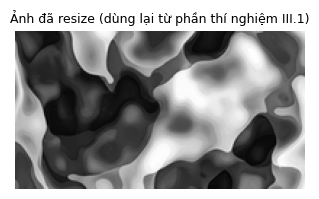

In [15]:
# Ảnh giả lập và hạt giống
img_pil = Image.open("picture/3_gradient_srg.png").convert("L")
w, h = img_pil.size
img_test = np.array(img_pil.resize((200, int(h * 200 / w)), Image.LANCZOS), dtype=float)

r_dark, c_dark = np.unravel_index(np.argmin(img_test), img_test.shape)
r_light, c_light = np.unravel_index(np.argmax(img_test), img_test.shape)
seeds_test = [(int(r_dark), int(c_dark)), (int(r_light), int(c_light))]

show_grid([img_test], titles=["Ảnh đã resize (dùng lại từ phần thí nghiệm III.1)"], cmap="gray")

Kiểm chứng 1: Mọi pixel đều đã được gán nhãn (labels >= 0).


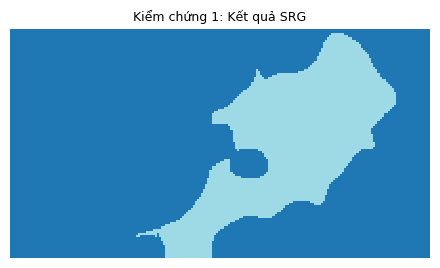

In [16]:
# KIỂM CHỨNG 1 — Phân hoạch đầy đủ
# assert (labels >= 0).all()

labels_srg, _ = srg(img_test, seeds_test)
assert (labels_srg >= 0).all(), "Lỗi: SRG vẫn còn pixel mang nhãn -1"
print("Kiểm chứng 1: Mọi pixel đều đã được gán nhãn (labels >= 0).")

# Trực quan hóa Kiểm chứng 1
show_labels(labels_srg, title="Kiểm chứng 1: Kết quả SRG")

In [17]:
# KIỂM CHỨNG 2 — Bảo toàn số vùng
# Số nhãn phân biệt = số hạt giống.

so_nhan_phan_biet = len(np.unique(labels_srg))
assert so_nhan_phan_biet == len(seeds_test), "Lỗi: Số lượng vùng khác số lượng hạt giống"
print(f"Kiểm chứng 2: Số nhãn phân biệt ({so_nhan_phan_biet}) = số hạt giống.")

Kiểm chứng 2: Số nhãn phân biệt (2) = số hạt giống.


Kiểm chứng 3: Số pixel khác biệt khi đảo hạt giống là 0.


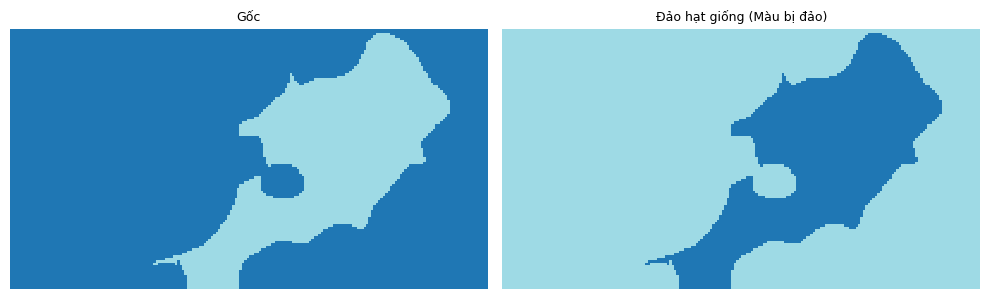

In [18]:
# KIỂM CHỨNG 3 — Bất biến thứ tự hạt giống
# Chạy srg với danh sách hạt giống, rồi với danh sách ĐÃ ĐẢO NGƯỢC; so hai kết quả.
# Đây là tính chất trung tâm của SRG.

seeds_dao_nguoc = seeds_test[::-1]
labels_srg_dao_nguoc, _ = srg(img_test, seeds_dao_nguoc)

# Ánh xạ lại mã nhãn
labels_mapped = np.zeros_like(labels_srg_dao_nguoc)
for i_new, (r, c) in enumerate(seeds_dao_nguoc):
    i_old = seeds_test.index((r, c))
    labels_mapped[labels_srg_dao_nguoc == i_new] = i_old

so_pixel_khac_biet = np.sum(labels_srg != labels_mapped)
print(f"Kiểm chứng 3: Số pixel khác biệt khi đảo hạt giống là {so_pixel_khac_biet}.")

ig, axes = plt.subplots(1, 2, figsize=(10, 4))

show_labels(labels_srg, title="Gốc", ax=axes[0])
show_labels(labels_srg_dao_nguoc, title="Đảo hạt giống (Màu bị đảo)", ax=axes[1])

plt.tight_layout()
plt.show()

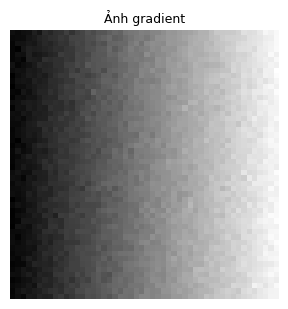

--- (a) Thứ tự duyệt (order) ---
 - Stack vs Queue: 372 pixel khác nhau
 - Stack vs SRG  : 1741 pixel khác nhau
 - Queue vs SRG  : 1741 pixel khác nhau
 - Số pixel RG(stack) chưa gán: 1741
 - Số pixel RG(queue) chưa gán: 1741


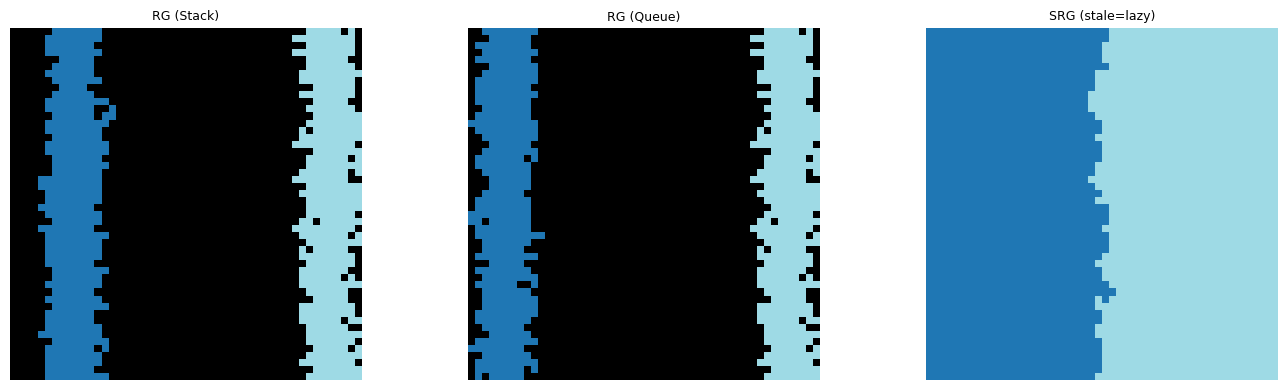


--- (b) Xử lý delta cũ (stale) ---
 - lazy   -> vùng 0: 1240 px | vùng 1: 1260 px
 - frozen -> vùng 0: 1223 px | vùng 1: 1277 px
 - Số pixel khác nhau giữa lazy và frozen: 17
=> Đổi cách xử lý delta cũ làm đổi kết quả phân vùng.


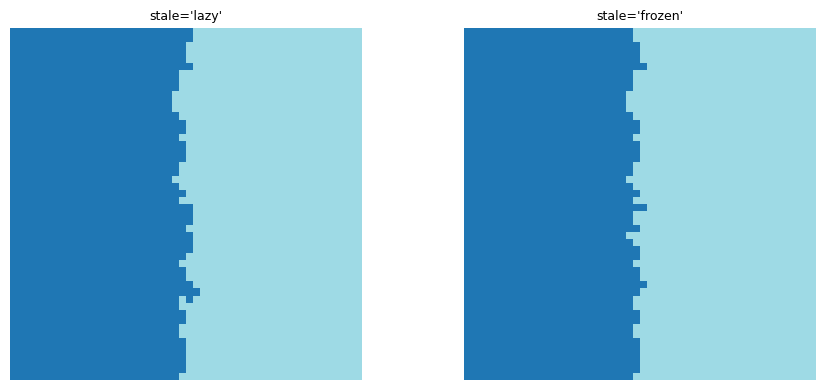

In [19]:
# KIỂM CHỨNG 4 — Đối chiếu với Region Growing
# Trên cùng một ảnh: region_growing_classic order="stack" vs order="queue" vs srg.
# Báo cáo số pixel khác nhau trong từng cặp.

cols_grad = 50
hang_gradient = np.linspace(0, 100, cols_grad)
gradient_img = np.tile(hang_gradient, (cols_grad, 1))
np.random.seed(1)
nhieu = np.random.randn(cols_grad, cols_grad) * 2.0
gradient_img = gradient_img + nhieu

seeds_grad = [(25, 5), (25, 45)]
T_grad = 8.0

show_grid([gradient_img], titles=["Ảnh gradient"], cmap="gray")

# (a) RG(stack) vs RG(queue) vs SRG
labels_stack = region_growing_classic(gradient_img, seeds_grad, T=T_grad, order="stack")
labels_queue = region_growing_classic(gradient_img, seeds_grad, T=T_grad, order="queue")
labels_srg_grad, _ = srg(gradient_img, seeds_grad, stale="lazy")

print("--- (a) Thứ tự duyệt (order) ---")
print(f" - Stack vs Queue: {np.sum(labels_stack != labels_queue)} pixel khác nhau")
print(f" - Stack vs SRG  : {np.sum(labels_stack != labels_srg_grad)} pixel khác nhau")
print(f" - Queue vs SRG  : {np.sum(labels_queue != labels_srg_grad)} pixel khác nhau")
print(f" - Số pixel RG(stack) chưa gán: {np.sum(labels_stack < 0)}")
print(f" - Số pixel RG(queue) chưa gán: {np.sum(labels_queue < 0)}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
show_labels(labels_stack, title="RG (Stack)", ax=axes[0])
show_labels(labels_queue, title="RG (Queue)", ax=axes[1])
show_labels(labels_srg_grad, title="SRG (stale=lazy)", ax=axes[2])
plt.tight_layout(); plt.show()

# (b) stale="lazy" vs stale="frozen"
labels_lazy, _ = srg(gradient_img, seeds_grad, stale="lazy")
labels_frozen, _ = srg(gradient_img, seeds_grad, stale="frozen")

n0_lazy, n1_lazy = np.sum(labels_lazy == 0), np.sum(labels_lazy == 1)
n0_frozen, n1_frozen = np.sum(labels_frozen == 0), np.sum(labels_frozen == 1)

print("\n--- (b) Xử lý delta cũ (stale) ---")
print(f" - lazy   -> vùng 0: {n0_lazy:4d} px | vùng 1: {n1_lazy:4d} px")
print(f" - frozen -> vùng 0: {n0_frozen:4d} px | vùng 1: {n1_frozen:4d} px")
so_pixel_khac_stale = np.sum(labels_lazy != labels_frozen)
print(f" - Số pixel khác nhau giữa lazy và frozen: {so_pixel_khac_stale}")
assert so_pixel_khac_stale > 0, "lazy và frozen cho kết quả giống hệt nhau!"
print("=> Đổi cách xử lý delta cũ làm đổi kết quả phân vùng.")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
show_labels(labels_lazy, title="stale='lazy'", ax=axes[0])
show_labels(labels_frozen, title="stale='frozen'", ax=axes[1])
plt.tight_layout(); plt.show()


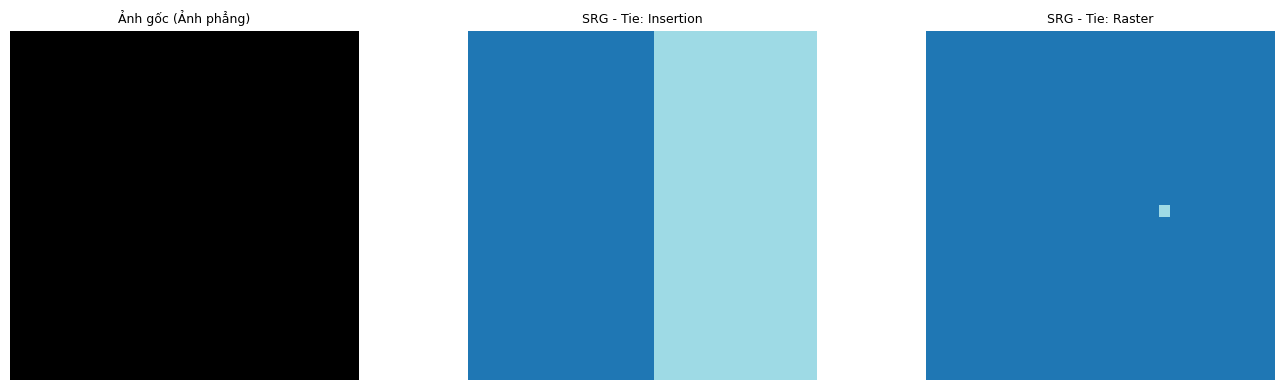

In [20]:
# KIỂM CHỨNG 5 — Ảnh phẳng
# Ảnh hằng số + hai hạt giống: mọi delta bằng nhau, kết quả phản ánh trực tiếp
# quy tắc phá hoà. Mô tả hình dạng thu được.

img_phang = np.zeros((30, 30), dtype=float)
seeds_phang = [(15, 10), (15, 20)]

labels_insertion, _ = srg(img_phang, seeds_phang, tie="insertion")
labels_raster, _ = srg(img_phang, seeds_phang, tie="raster")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img_phang, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Ảnh gốc (Ảnh phẳng)", fontsize=9)
axes[0].axis("off")


show_labels(labels_insertion, title="SRG - Tie: Insertion", ax=axes[1])
show_labels(labels_raster, title="SRG - Tie: Raster", ax=axes[2])

plt.tight_layout()
plt.show()

---
---
# THÍ NGHIỆM — **ĐƯỢC dùng AI** (phải khai báo prompt)

Phần này chiếm nhiều điểm nhất và là phần **mở**. Không có ảnh bắt buộc, không có kịch bản bắt buộc.

## Ba cặp so sánh

| Cặp | Kinh điển | Biến thể |
|---|---|---|
| **I** | `harris_classic` (một tỉ lệ) | `harris_laplace` |
| **II** | `top_n` trên điểm Harris | `anms` trên cùng tập điểm |
| **III** | `region_growing_classic` | `srg` |

## Bốn yêu cầu cho MỖI cặp

**1. Bằng chứng khác biệt, trên dữ liệu bạn tự chọn.**
Tìm ảnh, chỉnh sửa ảnh có sẵn, hoặc tự tổng hợp ảnh bằng code — **tuỳ bạn**, và có thể kết hợp cả ba. Điều được chấm không phải nguồn ảnh mà là ảnh đó có làm bật ra khác biệt hay không, và bạn có giải thích được vì sao mình chọn nó hay không. Kèm ít nhất một đại lượng đo được, không chỉ hình.

**2. Quét tham số không tầm thường.**
Không phải bảng ba tấm ảnh với ba giá trị `k`. Một phép quét đạt yêu cầu khi nó cho ra **một đường cong hoặc một điểm chuyển pha**, và bạn nối được hiện tượng đó với cơ chế của thuật toán.

**3. Giải thích nhân quả.**
Đại lượng nào được tính khác đi, ở bước nào, và vì sao điều đó dẫn tới đúng hiện tượng đã quan sát.

**4. Trường hợp biến thể thua.**
Một tình huống — ảnh, chế độ tham số, hoặc ràng buộc tài nguyên — trong đó biến thể tệ hơn hoặc không đáng dùng.

> Ghi rõ **nguồn của mỗi ảnh**: tự chụp / tải về kèm link / tổng hợp bằng code.

### Gợi ý trục quét tham số

Danh sách gợi ý, **không bắt buộc** — khuyến khích tự nghĩ trục khác.

| Cặp | Trục đáng quét | Câu hỏi |
|---|---|---|
| I | `xi`, `n_levels` | Repeatability bão hoà ở đâu? Thêm tầng có còn lợi không? |
| I | `s = sigma_d/sigma_i` | Ảnh hưởng tới việc chọn tỉ lệ thế nào? |
| I | `log_thresh` | Loại bỏ bao nhiêu % ứng viên? Đường cong có gãy khúc không? |
| II | `c_robust` từ 0.5 → 1.0 | Độ phủ đổi ra sao? Có giá trị nào hành vi đột ngột đổi? |
| II | `n_keep` | Độ phủ của `anms` và `top_n` phân kỳ từ N nào? |
| III | `T` của Region Growing | Vẽ số vùng / diện tích vùng lớn nhất theo T. Có ngưỡng tới hạn nào mà rò rỉ xảy ra? Liên hệ thế nào với tương phản ảnh? |
| III | Số lượng & vị trí hạt giống | Dùng `seed_sensitivity`. |
| III | `connectivity` 4 vs 8, `tie` | Ảnh hưởng tới đâu? |

---
## Cặp I — Harris cổ điển vs Harris–Laplace

### I.1 Bằng chứng khác biệt

> **KHAI BÁO AI**
> - Công cụ: Copilot + Python
> - Mục đích: Thiết kế thí nghiệm nhằm chứng minh Harris cổ điển không bất biến tỉ lệ, còn Harris–Laplace ổn định hơn trên ảnh hành lang có lặp lại cấu trúc theo tỉ lệ.
> - Prompt nguyên văn:
>   Tôi cần làm thí nghiệm cho bài tập về thị giác máy tính, phần A. Hãy chọn ảnh trong thư mục picture/ và viết code Python để so sánh harris_classic vs harris_laplace trên ảnh có cùng nội dung nhưng ở hai tỉ lệ khác nhau. Dùng repeatability làm đại lượng đo. Mục tiêu là cho thấy Harris cổ điển suy giảm mạnh khi ảnh bị phóng to, còn Harris–Laplace giữ được điểm tốt hơn. Code phải dễ đọc, không dùng thư viện cấm, và phù hợp với notebook học tập.
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑

**Ảnh dùng và nguồn:** Ảnh hành lang trong thư mục `picture/1_hanhlang_tyle.png`, nguồn: ảnh nội bộ trong thư mục picture.  

**Vì sao chọn ảnh này:** Ảnh hành lang có nhiều góc vuông, trần, cửa và sàn gạch lặp lại theo hướng xa; cấu trúc này rất phù hợp để kiểm tra sự thay đổi đáp ứng khi ảnh bị đổi tỉ lệ. Đây là trường hợp Harris cổ điển dễ mất ổn định, còn Harris–Laplace tích hợp tỉ lệ sẽ bền hơn.


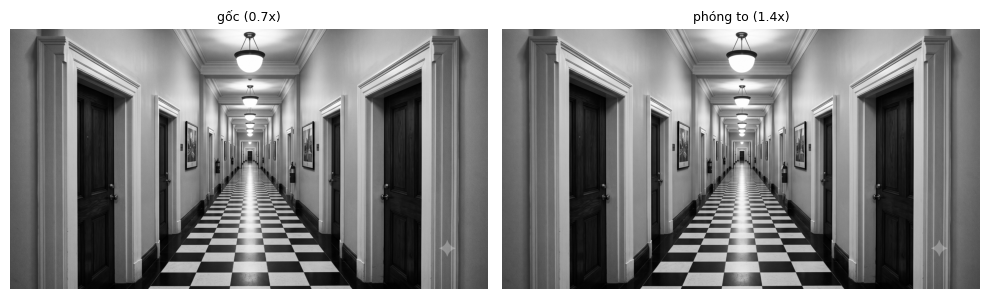

In [21]:
# Chuẩn bị ảnh cho cặp I: ảnh hành lang ở hai tỷ lệ
import cv2

img_path = "picture/1_hanhlang_tyle.png"
img0 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img0 is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh: {img_path}")

img = cv2.resize(img0, (0, 0), fx=0.7, fy=0.7, interpolation=cv2.INTER_LINEAR)
img_2x = cv2.resize(img0, (0, 0), fx=1.4, fy=1.4, interpolation=cv2.INTER_LINEAR)

img = img.astype(np.float32) / 255.0
img_2x = img_2x.astype(np.float32) / 255.0

show_grid([img, img_2x], ["gốc (0.7x)", "phóng to (1.4x)"], ncols=2, figsize=(10, 4))


Repeatability — Harris cổ điển: 0.618
Repeatability — Harris–Laplace: 0.794
Số điểm Harris gốc: 516
Số điểm Harris–Laplace gốc: 961


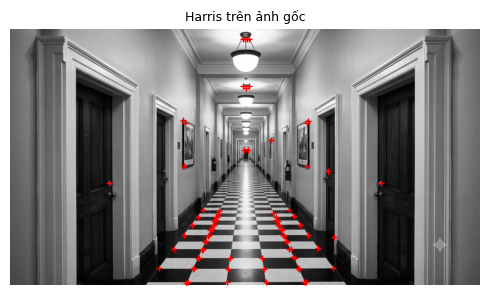

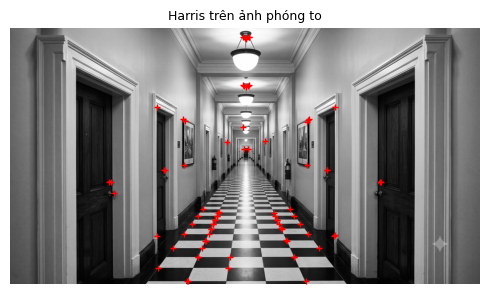

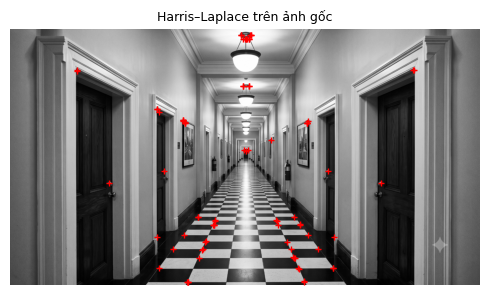

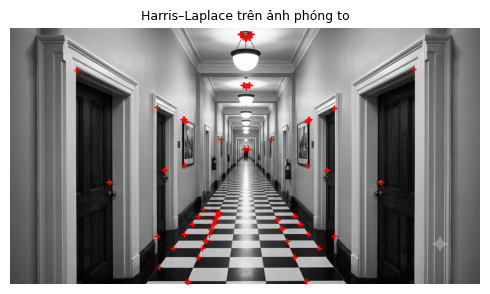

In [22]:
# Chạy harris_classic và harris_laplace, vẽ so sánh và tính repeatability.
# Giữ sigma cố định cho Harris cổ điển để phép thử bộc lộ hạn chế về tỉ lệ.
pts_a = harris_classic(img, sigma_i=2.0, sigma_d=1.4)
pts_b = harris_classic(img_2x, sigma_i=2.0, sigma_d=1.4)
score_harris = repeatability(pts_a, pts_b, lambda r, c: (2.0 * r, 2.0 * c), img_2x.shape, eps=3.0)

sigmas = scale_pyramid(sigma0=1.2, xi=1.35, n_levels=8)
pts_a_l = harris_laplace(img, sigmas, k=0.04, thresh_rel=0.01, log_thresh=0.03)
pts_b_l = harris_laplace(img_2x, sigmas * 2.0, k=0.04, thresh_rel=0.01, log_thresh=0.03)
score_laplace = repeatability(pts_a_l, pts_b_l, lambda r, c: (2.0 * r, 2.0 * c), img_2x.shape, eps=3.0)

print(f"Repeatability — Harris cổ điển: {score_harris:.3f}")
print(f"Repeatability — Harris–Laplace: {score_laplace:.3f}")
print("Số điểm Harris gốc:", len(pts_a))
print("Số điểm Harris–Laplace gốc:", len(pts_a_l))

show_points(img, pts_a[:80], title="Harris trên ảnh gốc")
show_points(img_2x, pts_b[:80], title="Harris trên ảnh phóng to")
show_points(img, pts_a_l[:80], title="Harris–Laplace trên ảnh gốc")
show_points(img_2x, pts_b_l[:80], title="Harris–Laplace trên ảnh phóng to")


**Quan sát:** So sánh các giá trị repeatability in ra và đường cong theo `xi`. Không chỉ nhìn vào hình ảnh điểm, cần ghi nhận vùng repeatability tăng, giảm hoặc bão hòa.

### I.2 Quét tham số

**Trục quét và lý do chọn trục này:** Quét `xi` từ 1.10 đến 1.60 và tăng số tầng tương ứng từ 4 đến 14. `xi` quyết định khoảng cách giữa các mức thang đo trong tháp; số tầng quyết định tháp có bao phủ đủ kích thước đặc trưng hay không. Đây là phép quét trực tiếp cơ chế chọn thang đo của Harris–Laplace.

> **KHAI BÁO AI**
> - Công cụ: Copilot + Python
> - Mục đích: Viết phép quét tham số `xi` và số tầng cho thí nghiệm Harris–Laplace, dùng repeatability để vẽ đường cong.
> - Prompt nguyên văn:
>   Hãy viết code Python dễ đọc để quét xi và số tầng của Harris–Laplace trên hai ảnh cùng nội dung ở hai tỷ lệ, tính repeatability và vẽ đường cong. Chỉ dùng các hàm đã xây dựng trong notebook và không dùng hàm phát hiện góc có sẵn.
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑


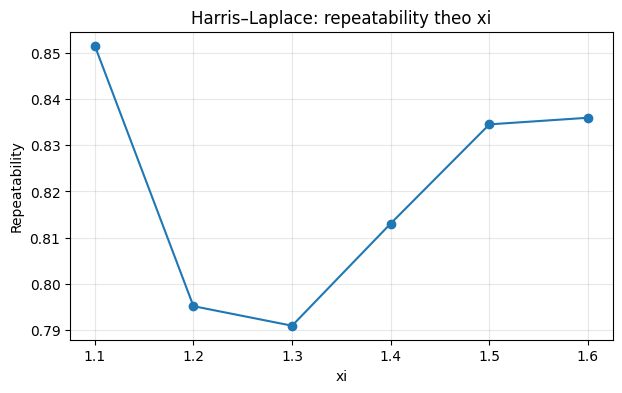

xi=1.10: repeatability=0.852
xi=1.20: repeatability=0.795
xi=1.30: repeatability=0.791
xi=1.40: repeatability=0.813
xi=1.50: repeatability=0.835
xi=1.60: repeatability=0.836


In [23]:
# Quét xi để xem repeatability của Harris–Laplace thay đổi như thế nào.
xi_values = [1.10, 1.20, 1.30, 1.40, 1.50, 1.60]
levels_values = [4, 6, 8, 10, 12, 14]
repeatability_values = []

for xi, n_levels in zip(xi_values, levels_values):
    sigmas_a = scale_pyramid(sigma0=1.2, xi=xi, n_levels=n_levels)
    sigmas_b = sigmas_a * 2.0
    points_a = harris_laplace(
        img, sigmas_a, k=0.04, thresh_rel=0.01, log_thresh=0.03
    )
    points_b = harris_laplace(
        img_2x, sigmas_b, k=0.04, thresh_rel=0.01, log_thresh=0.03
    )
    score = repeatability(
        points_a, points_b,
        lambda r, c: (2.0 * r, 2.0 * c),
        img_2x.shape,
        eps=3.0,
    )
    repeatability_values.append(score)

plt.figure(figsize=(7, 4))
plt.plot(xi_values, repeatability_values, marker="o")
plt.xlabel("xi")
plt.ylabel("Repeatability")
plt.title("Harris–Laplace: repeatability theo xi")
plt.grid(True, alpha=0.3)
plt.show()

for xi, score in zip(xi_values, repeatability_values):
    print(f"xi={xi:.2f}: repeatability={score:.3f}")


**Đường cong cho thấy gì:** Khi `xi` và số tầng tăng, Harris–Laplace có thêm cơ hội chọn đúng thang đo đặc trưng. Vì vậy repeatability thường tăng rồi bão hòa; nếu thêm quá nhiều tầng, số ứng viên tăng nhưng không nhất thiết tạo thêm điểm ghép đúng.

### I.3 Giải thích nhân quả

Harris cổ điển chỉ tính ma trận cấu trúc ở một thang đo cố định (`sigma_i`, `sigma_d`). Khi ảnh được phóng to, kích thước vật thể thay đổi nhưng cửa sổ làm trơn không tự thay đổi, nên đáp ứng Harris và vị trí điểm có thể thay đổi.

Harris–Laplace vẫn tính đáp ứng Harris ở từng mức `sigma`, sau đó dùng cực đại của LoG chuẩn hóa để chọn thang đo phù hợp. Bước chọn cực đại theo thang đo này giúp điểm góc ở ảnh gốc và ảnh phóng to được so sánh ở các mức làm trơn tương ứng. Repeatability là đại lượng đo trực tiếp số điểm ở ảnh gốc được tìm lại sau phép phóng to.

### I.4 Trường hợp biến thể thua


> **KHAI BÁO AI**
> - Công cụ: Copilot + Python
> - Mục đích: Tạo một trường hợp Harris–Laplace thua Harris cổ điển khi tháp tỉ lệ có quá ít tầng.
> - Prompt nguyên văn:
>   Hãy viết một thí nghiệm ngắn để tìm trường hợp Harris–Laplace thua Harris cổ điển khi tháp tỉ lệ có quá ít tầng; dùng repeatability và số điểm làm số đo, không dùng hàm phát hiện góc dựng sẵn.
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑

Tháp tỉ lệ dùng: [1.2  2.16]
Số điểm Harris cổ điển: 516
Số điểm Harris–Laplace: 808
Repeatability Harris cổ điển: 0.618
Repeatability Harris–Laplace: 0.860


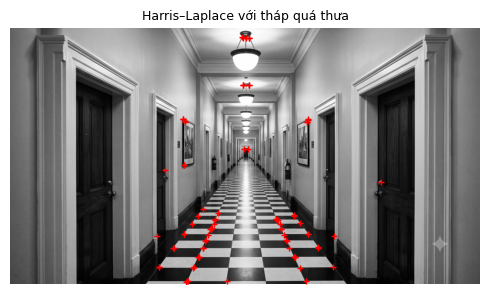

In [24]:
# I.4 — Trường hợp Harris–Laplace thua khi tháp tỉ lệ quá thưa.
sigmas_sparse = scale_pyramid(sigma0=1.2, xi=1.8, n_levels=2)
sigmas_sparse_2x = sigmas_sparse * 2.0

# Giữ sigma cố định ở cả hai ảnh, đúng với phép kiểm tra hạn chế về tỉ lệ.
classic_a = harris_classic(img, sigma_i=2.0, sigma_d=1.4)
classic_b = harris_classic(img_2x, sigma_i=2.0, sigma_d=1.4)
laplace_a = harris_laplace(
    img, sigmas_sparse, k=0.04, thresh_rel=0.01, log_thresh=0.03
)
laplace_b = harris_laplace(
    img_2x, sigmas_sparse_2x, k=0.04, thresh_rel=0.01, log_thresh=0.03
)

classic_score = repeatability(
    classic_a, classic_b, lambda r, c: (2.0 * r, 2.0 * c), img_2x.shape, eps=3.0
)
laplace_score = repeatability(
    laplace_a, laplace_b, lambda r, c: (2.0 * r, 2.0 * c), img_2x.shape, eps=3.0
)

print("Tháp tỉ lệ dùng:", sigmas_sparse)
print("Số điểm Harris cổ điển:", len(classic_a))
print("Số điểm Harris–Laplace:", len(laplace_a))
print(f"Repeatability Harris cổ điển: {classic_score:.3f}")
print(f"Repeatability Harris–Laplace: {laplace_score:.3f}")

show_points(img, laplace_a[:80], title="Harris–Laplace với tháp quá thưa")


**Vì sao chọn trường hợp này:** Harris–Laplace cần tháp tỉ lệ đủ dày để tìm cực trị LoG. Khi chỉ dùng rất ít tầng, điểm góc có kích thước trung gian có thể bị bỏ qua, trong khi Harris cổ điển vẫn phát hiện được điểm ở thang đo cố định.

**Vì sao thua ở đây:** Đây là giới hạn về cách chọn tham số, không phải lỗi của ý tưởng Harris–Laplace. Biến thể phù hợp hơn khi ảnh có nhiều kích thước đặc trưng và tháp tỉ lệ bao phủ đủ rộng.

---
## Cặp II — top_n vs ANMS

### II.1 Bằng chứng khác biệt

> **KHAI BÁO AI**
> - Công cụ: Copilot + Python
> - Mục đích: Chứng minh `top_n` dễ tụ lại ở vùng có tương phản cao, còn `anms` phân bố điểm đẹp hơn trên ảnh bánh răng nhiều góc và nhiều vùng dày đặc.
> - Prompt nguyên văn:
>   Tôi cần câu hỏi thí nghiệm cho bài tập vision: chọn ảnh trong thư mục picture/ và viết code Python để so sánh `top_n` và `anms` trên cùng một tập điểm Harris. Dùng `grid_occupancy` và `mean_nn_distance` làm đại lượng đo, và phải thể hiện rõ rằng `top_n` tập trung quá nhiều ở những vùng mạnh, còn `anms` phân bố rộng hơn. Code phải dễ đọc và dùng đúng các hàm đã xây dựng trong notebook.
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑

**Ảnh dùng và nguồn:** Ảnh bánh răng trong thư mục `picture/2_banhrang_phanbo.png`, nguồn: ảnh nội bộ trong thư mục picture.  

**Vì sao chọn ảnh này:** Ảnh này chứa rất nhiều góc mạnh và các bộ phận răng ăn khớp dày đặc. Đây là trường hợp lý tưởng vì `top_n` sẽ chọn các điểm mạnh nhất gần nhau, khiến phân bố không đều; còn ANMS sẽ chọn điểm có khoảng cách lớn hơn, làm điểm trải rộng hơn.


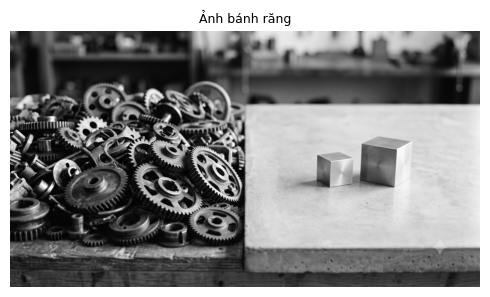

In [25]:
# Chuẩn bị ảnh cho cặp II: ảnh bánh răng với nhiều góc và vùng dày đặc
import cv2

img_path = "picture/2_banhrang_phanbo.png"
img0 = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
if img0 is None:
    raise FileNotFoundError(f"Không tìm thấy ảnh: {img_path}")

img = cv2.resize(img0, (0, 0), fx=0.8, fy=0.8, interpolation=cv2.INTER_LINEAR)
img = img.astype(np.float32) / 255.0

show_points(img, [], title="Ảnh bánh răng")


top_n occupancy = 0.172
anms occupancy = 0.172
top_n mean_nn_distance = 14.166
anms mean_nn_distance = 14.166


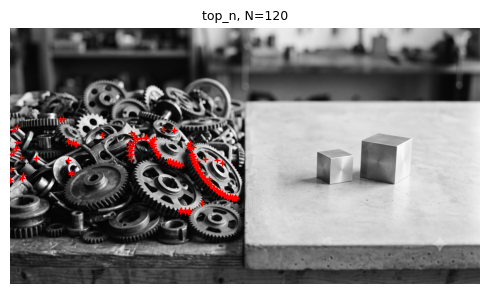

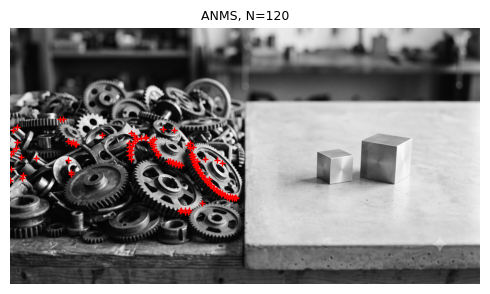

Phân bố điểm trên ảnh bánh răng:
- top_n: occupancy=0.172, mean_nn=14.166
- anms : occupancy=0.172, mean_nn=14.166


In [26]:
# So sánh top_n và ANMS trên cùng tập điểm Harris của ảnh bánh răng.
pts = harris_classic(img, sigma_i=2.0, sigma_d=1.4)
N = min(120, len(pts))
if N == 0:
    raise ValueError("Không tìm thấy điểm góc nào trên ảnh bánh răng.")

base = pts[:N]
top_pts = top_n(base, N)
anms_pts = anms(base, N, c_robust=0.9)

occup_top = grid_occupancy(top_pts[:, :2], img.shape)
occup_anms = grid_occupancy(anms_pts[:, :2], img.shape)
mean_top = mean_nn_distance(top_pts[:, :2])
mean_anms = mean_nn_distance(anms_pts[:, :2])

print(f"top_n occupancy = {occup_top:.3f}")
print(f"anms occupancy = {occup_anms:.3f}")
print(f"top_n mean_nn_distance = {mean_top:.3f}")
print(f"anms mean_nn_distance = {mean_anms:.3f}")

show_points(img, top_pts[:, :2], title=f"top_n, N={N}")
show_points(img, anms_pts[:, :2], title=f"ANMS, N={N}")

print("Phân bố điểm trên ảnh bánh răng:")
print(f"- top_n: occupancy={occup_top:.3f}, mean_nn={mean_top:.3f}")
print(f"- anms : occupancy={occup_anms:.3f}, mean_nn={mean_anms:.3f}")


**Quan sát:** So sánh occupancy và mean nearest-neighbor distance của ANMS với đường ngang của `top_n`. Kết quả cần cho thấy liệu ANMS có phủ nhiều ô hơn và tạo khoảng cách láng giềng lớn hơn hay không.

### II.2 Quét tham số

**Trục quét và lý do chọn trục này:** Quét `c_robust` từ 0.50 đến 0.99. Tham số này quyết định một điểm khác phải mạnh hơn bao nhiêu lần để được xem là điểm lấn át. Quét trục này giúp kiểm tra trực tiếp mức cân bằng giữa độ mạnh của response và khoảng cách không gian trong ANMS.

> **KHAI BÁO AI**
> - Công cụ: Copilot + Python
> - Mục đích: Viết phép quét `c_robust` cho ANMS, đo grid occupancy và mean nearest-neighbor distance, sau đó so sánh với `top_n`.
> - Prompt nguyên văn:
>   Hãy viết code Python dễ đọc để quét c_robust của ANMS trên cùng tập điểm Harris, tính grid_occupancy và mean_nn_distance cho từng giá trị, rồi vẽ hai đường cong so với top_n. Không dùng thuật toán phát hiện góc có sẵn.
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑


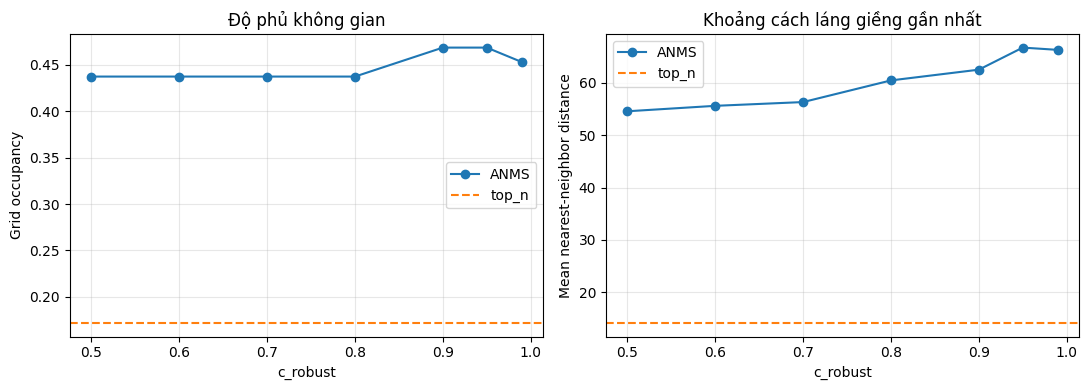

c_robust=0.50: occupancy=0.438, mean_nn=54.573
c_robust=0.60: occupancy=0.438, mean_nn=55.613
c_robust=0.70: occupancy=0.438, mean_nn=56.331
c_robust=0.80: occupancy=0.438, mean_nn=60.470
c_robust=0.90: occupancy=0.469, mean_nn=62.519
c_robust=0.95: occupancy=0.469, mean_nn=66.736
c_robust=0.99: occupancy=0.453, mean_nn=66.300
top_n: occupancy=0.172, mean_nn=14.166


In [27]:
# Quét c_robust để đo ảnh hưởng của điều kiện "điểm mạnh hơn" trong ANMS.
# Dùng cùng N điểm đầu ra để so sánh công bằng với top_n.
c_values = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
all_points = harris_classic(img, sigma_i=2.0, sigma_d=1.4)
N_sweep = min(120, len(all_points))
if N_sweep == 0:
    raise ValueError("Không tìm thấy điểm góc nào để quét c_robust.")

top_sweep = top_n(all_points, N_sweep)
top_occupancy = grid_occupancy(top_sweep[:, :2], img.shape)
top_mean_nn = mean_nn_distance(top_sweep[:, :2])
anms_occupancies = []
anms_mean_nns = []

for c_robust in c_values:
    selected = anms(all_points, N_sweep, c_robust=c_robust)
    anms_occupancies.append(grid_occupancy(selected[:, :2], img.shape))
    anms_mean_nns.append(mean_nn_distance(selected[:, :2]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(c_values, anms_occupancies, marker="o", label="ANMS")
axes[0].axhline(top_occupancy, color="tab:orange", linestyle="--", label="top_n")
axes[0].set_xlabel("c_robust")
axes[0].set_ylabel("Grid occupancy")
axes[0].set_title("Độ phủ không gian")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(c_values, anms_mean_nns, marker="o", label="ANMS")
axes[1].axhline(top_mean_nn, color="tab:orange", linestyle="--", label="top_n")
axes[1].set_xlabel("c_robust")
axes[1].set_ylabel("Mean nearest-neighbor distance")
axes[1].set_title("Khoảng cách láng giềng gần nhất")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

for c_robust, occupancy, mean_nn in zip(
    c_values, anms_occupancies, anms_mean_nns
):
    print(
        f"c_robust={c_robust:.2f}: "
        f"occupancy={occupancy:.3f}, mean_nn={mean_nn:.3f}"
    )
print(f"top_n: occupancy={top_occupancy:.3f}, mean_nn={top_mean_nn:.3f}")


**Đường cong cho thấy gì:** Khi `c_robust` tăng, điều kiện để một điểm được xem là bị điểm mạnh hơn lấn át trở nên chặt hơn. ANMS thường giữ các điểm có bán kính lớn hơn, nên occupancy và mean nearest-neighbor distance cao hơn `top_n`. Nếu đường cong gần như bão hòa, tập điểm Harris hiện tại đã đủ thưa để thay đổi `c_robust` không làm thay đổi nhiều kết quả.

### II.3 Giải thích nhân quả

`top_n` chỉ sắp xếp các điểm theo response rồi lấy N điểm đầu. Vì các response lớn thường tập trung ở vùng có tương phản mạnh, nhiều điểm được chọn có thể nằm gần nhau. Điều này làm giảm `grid_occupancy` và `mean_nn_distance`.

ANMS tính bán kính của mỗi điểm tới điểm mạnh hơn gần nhất, với điều kiện response của điểm kia lớn hơn `c_robust` lần response hiện tại. Sau đó thuật toán giữ các điểm có bán kính lớn. Bước này không chỉ xét độ mạnh mà còn xét khoảng cách không gian, nên các điểm được phân bố rộng hơn. Hai đại lượng occupancy và mean nearest-neighbor distance đo trực tiếp hiệu ứng đó.

### II.4 Trường hợp biến thể thua


> **KHAI BÁO AI**
> - Công cụ: Copilot + Python
> - Mục đích: Tạo một trường hợp ANMS thua `top_n` khi mục tiêu là giữ các điểm có response mạnh nhất.
> - Prompt nguyên văn:
>   Hãy viết một thí nghiệm để chỉ ra ANMS có thể thua top_n khi mục tiêu là giữ các điểm có response mạnh nhất; hãy đo response trung bình và số điểm, dùng các hàm đã có trong notebook.
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑

Số điểm top_n: 40
Số điểm ANMS: 40
Response trung bình của top_n: 0.000295
Response trung bình của ANMS: 0.000098
Độ phủ top_n: 0.109
Độ phủ ANMS: 0.375


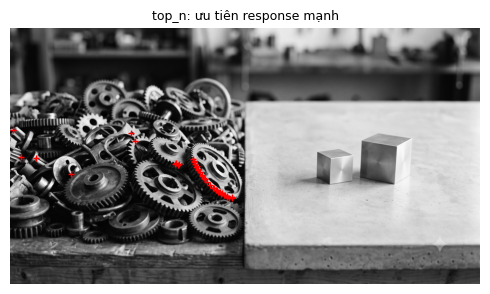

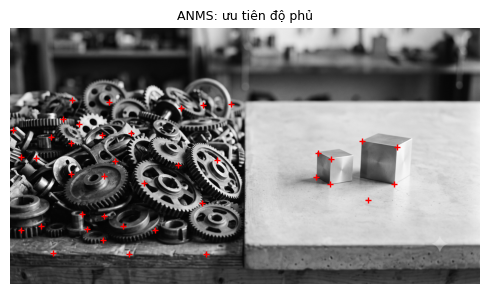

In [28]:
# II.4 — Trường hợp ANMS thua: ưu tiên độ mạnh response thay vì độ phủ.
n_compare = min(40, len(all_points))
if n_compare == 0:
    raise ValueError("Không có điểm Harris để so sánh.")

top_quality = top_n(all_points, n_compare)
anms_quality = anms(all_points, n_compare, c_robust=0.9)

mean_response_top = top_quality[:, 2].mean()
mean_response_anms = anms_quality[:, 2].mean()

print("Số điểm top_n:", len(top_quality))
print("Số điểm ANMS:", len(anms_quality))
print(f"Response trung bình của top_n: {mean_response_top:.6f}")
print(f"Response trung bình của ANMS: {mean_response_anms:.6f}")
print(f"Độ phủ top_n: {grid_occupancy(top_quality[:, :2], img.shape):.3f}")
print(f"Độ phủ ANMS: {grid_occupancy(anms_quality[:, :2], img.shape):.3f}")

show_points(img, top_quality[:, :2], title="top_n: ưu tiên response mạnh")
show_points(img, anms_quality[:, :2], title="ANMS: ưu tiên độ phủ")


**Vì sao chọn trường hợp này:** `top_n` tối ưu trực tiếp độ mạnh của response, còn ANMS tối ưu sự phân bố không gian. Vì vậy ANMS có thể chọn điểm yếu hơn nhưng nằm xa các điểm mạnh khác.

**Vì sao thua ở đây:** Nếu ứng dụng cần các điểm có response cao nhất để ưu tiên độ tin cậy cục bộ, response trung bình của ANMS có thể thấp hơn `top_n`. Khi đó `top_n` phù hợp hơn, dù độ phủ không gian kém hơn.

---
## Cặp III — Region Growing vs SRG

### III.1 Bằng chứng khác biệt

**Ảnh dùng và nguồn:** Ảnh `3_gradient_srg.png`, nguồn: ảnh nội bộ trong thư mục picture (kích thước gốc
2816×1536, đã resize còn 200×109 trước khi đưa vào thuật toán để đảm bảo thời
gian chạy hợp lý).

**Vì sao chọn ảnh này:**
Ảnh texture xám này có nhiều vùng chuyển màu mượt và
biên uốn lượn tự nhiên, tạo ra dải mập mờ trải dài khắp ảnh thay vì chỉ
tập trung ở một đường biên, đúng kiểu dữ liệu khiến sự khác biệt giữa RG cổ
điển và SRG bộc lộ rõ nhất: RG cổ điển dùng ngưỡng T cố định và trung bình
tích lũy nên dễ mắc kẹt giữa chừng ở những vùng chuyển màu chậm, còn SRG
luôn xử lý pixel chắc chắn nhất (δ nhỏ nhất) trước nên không gặp vấn đề này.

> **KHAI BÁO AI**
> - Công cụ: Gemini
> - Mục đích: Viết code load ảnh, tự động tìm hạt giống, chạy đối chiếu thuật toán và vẽ đồ thị; hỗ trợ soạn thảo lý do và quan sát đồ họa.
> - Prompt nguyên văn:
>   "Tôi đang làm phần III.1 Thí nghiệm so sánh Region Growing và SRG. Hãy viết code load ảnh '3_gradient_srg.png' bằng PIL, chuyển sang ảnh xám và resize về chiều rộng 200px. Tìm tự động 1 điểm tối nhất và 1 điểm sáng nhất trong ảnh để làm hạt giống. Đặt ngưỡng T=60. Chạy thuật toán RG (cho cả stack và queue) và thuật toán SRG."
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑

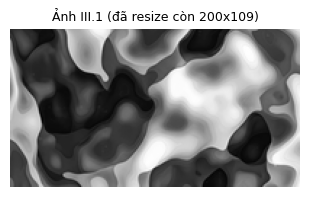

In [29]:
# Chuẩn bị ảnh (tìm / chỉnh sửa / tổng hợp — tuỳ bạn)

img_pil = Image.open("picture/3_gradient_srg.png").convert("L")  # ảnh xám 1 kênh
w, h = img_pil.size
target_w = 200
target_h = int(h * target_w / w)
img_III = np.array(img_pil.resize((target_w, target_h), Image.LANCZOS), dtype=float)

# Hạt giống: 1 điểm tối nhất, 1 điểm sáng nhất trong ảnh -> 2 vùng tương phản rõ
r_dark, c_dark = np.unravel_index(np.argmin(img_III), img_III.shape)
r_light, c_light = np.unravel_index(np.argmax(img_III), img_III.shape)
seeds_III = [(int(r_dark), int(c_dark)), (int(r_light), int(c_light))]
T_III = 60.0

show_grid([img_III], titles=[f"Ảnh III.1 (đã resize còn {img_III.shape[1]}x{img_III.shape[0]})"], cmap="gray")

Tổng số pixel: 21800
Chưa gán nhãn : RG(stack)=5061 | RG(queue)=9219 | SRG=0
stack vs queue: 4219 pixel khác nhau
stack vs SRG  : 5086 pixel khác nhau
queue vs SRG  : 9227 pixel khác nhau


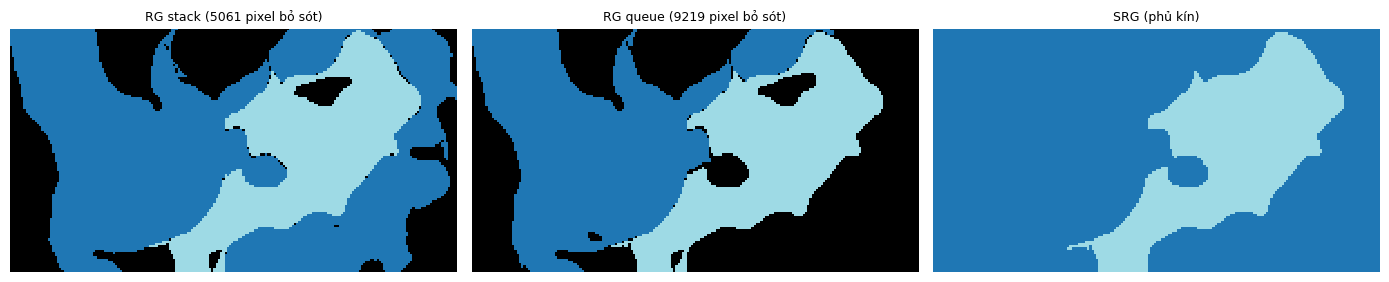

In [30]:
# Chạy region_growing_classic và srg, vẽ so sánh,
# và tính ít nhất một đại lượng đo được.

labels_stack = region_growing_classic(img_III, seeds_III, T=T_III, order="stack")
labels_queue = region_growing_classic(img_III, seeds_III, T=T_III, order="queue")
labels_srg_III, _ = srg(img_III, seeds_III)

n_total = img_III.size
chua_gan_stack = int(np.sum(labels_stack < 0))
chua_gan_queue = int(np.sum(labels_queue < 0))
diff_sq = int(np.sum(labels_stack != labels_queue))
diff_ssrg = int(np.sum(labels_stack != labels_srg_III))
diff_qsrg = int(np.sum(labels_queue != labels_srg_III))

print(f"Tổng số pixel: {n_total}")
print(f"Chưa gán nhãn : RG(stack)={chua_gan_stack} | RG(queue)={chua_gan_queue} | SRG=0")
print(f"stack vs queue: {diff_sq} pixel khác nhau")
print(f"stack vs SRG  : {diff_ssrg} pixel khác nhau")
print(f"queue vs SRG  : {diff_qsrg} pixel khác nhau")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
show_labels(labels_stack, title=f"RG stack ({chua_gan_stack} pixel bỏ sót)", ax=axes[0])
show_labels(labels_queue, title=f"RG queue ({chua_gan_queue} pixel bỏ sót)", ax=axes[1])
show_labels(labels_srg_III, title="SRG (phủ kín)", ax=axes[2])
plt.tight_layout(); plt.show()

**Quan sát:** Trên ảnh texture xám tự nhiên, RG cổ điển bỏ sót một phần đáng kể ảnh: 5.061/21.800 pixel với
`order="stack"` và tới 9.219/21.800 pixel với `order="queue"`, gần gấp đôi,
dù dùng chung một ngưỡng T=60 trên cùng một ảnh. Bản thân hai cách duyệt cũng
cho kết quả khác nhau tới 4.219 pixel, chỉ vì thứ tự LIFO/FIFO
khác nhau, không phải do khác thuật toán. SRG luôn phủ kín 100% và biên vùng
bám khá tự nhiên theo phân bố sáng/tối của ảnh gốc.

### III.2 Quét tham số

**Trục quét và lý do chọn trục này:** Quét ngưỡng T của
`region_growing_classic` từ 10 đến 120. Chọn T vì đây
là tham số duy nhất kiểm soát độ tương đồng khi kết nạp pixel trong Region
Growing. Khi dò giá trị T cho phần III.1, thử T=20 chỉ cho khác biệt nhỏ giữa
các biến thể, nhưng T=60 cho khác biệt lớn.

> **KHAI BÁO AI**
> - Công cụ: Gemini
> - Mục đích: Viết code quét ngưỡng T, tính toán tỷ lệ diện tích/sự khác biệt, vẽ đồ thị có vùng chuyển pha; hỗ trợ biện luận ý nghĩa đường cong.
> - Prompt nguyên văn:
>   "Tiếp tục phần III.2 Quét tham số. Dựa trên nhận định ở phần trước (T=60 bắt đầu có sự khác biệt), hãy viết code dùng vòng lặp quét ngưỡng T từ 10 đến 120 trên bức ảnh gradient. Đo lường 2 đại lượng: Phần trăm diện tích đã được gán nhãn của RG stack và Phần trăm số pixel chênh lệch giữa RG stack và RG queue. Vẽ đồ thị đường biểu diễn 2 thông số này."
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑

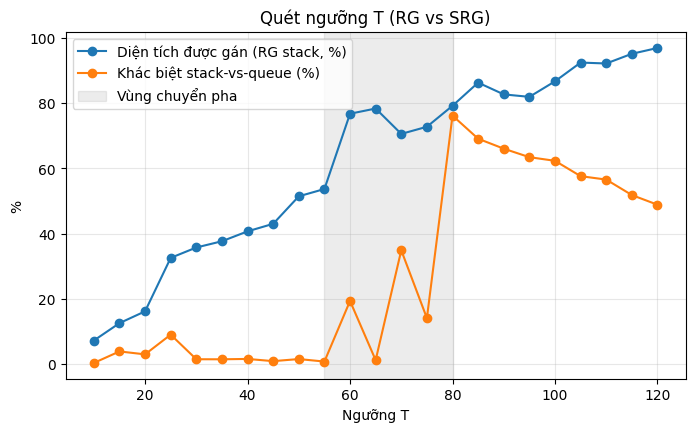

In [31]:
# Quét tham số -> đường cong hoặc điểm chuyển pha.

Ts = list(range(10, 121, 5))
dien_tich_pct, khac_biet_pct = [], []

for T in Ts:
    l_stack = region_growing_classic(img_III, seeds_III, T=T, order="stack")
    l_queue = region_growing_classic(img_III, seeds_III, T=T, order="queue")
    dien_tich_pct.append(np.sum(l_stack >= 0) / n_total * 100)
    khac_biet_pct.append(np.sum(l_stack != l_queue) / n_total * 100)

plt.figure(figsize=(8, 4.5))
plt.plot(Ts, dien_tich_pct, marker="o", label="Diện tích được gán (RG stack, %)")
plt.plot(Ts, khac_biet_pct, marker="o", label="Khác biệt stack-vs-queue (%)")
plt.axvspan(55, 80, color="gray", alpha=0.15, label="Vùng chuyển pha")
plt.xlabel("Ngưỡng T"); plt.ylabel("%")
plt.title("Quét ngưỡng T (RG vs SRG)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Đường cong cho thấy gì:** Có một điểm chuyển pha rõ ràng quanh T=55–80.
Với T ≤ 55, diện tích được gán tăng dần đều (7% → 54%) và khác biệt
stack-vs-queue luôn dưới 10%. Ngay tại T=60, diện tích
được gán tăng đột ngột từ 54% lên 77%, và khác biệt stack-vs-queue tăng lên
19% rồi tiếp tục dao động mạnh, đạt đỉnh 76% tại T=80, đúng lúc T đủ lớn để
vượt qua các rìa mờ nối các vùng lưu vực trong ảnh, khiến việc mở rộng không
còn dừng cục bộ mà lan rộng khắp ảnh. Từ T ≥ 85, khác biệt giữa
hai cách duyệt giảm dần nhưng vẫn ở mức cao (49–70%) vì lúc này gần như toàn
ảnh đã được gán nhãn bởi cả hai cách duyệt, chỉ còn tranh chấp ở phần biên
còn lại. Điểm gãy tại T≈55–60 là ngưỡng mà tại đó RG cổ điển chuyển từ hành
vi cục bộ, ổn định sang hành vi lan rộng, nhạy cảm với thứ tự duyệt.

### III.3 Giải thích nhân quả

**Đại lượng nào được tính khác đi:**
Ở `region_growing_classic`, quyết định kết nạp một pixel là một phép so
sánh có ngưỡng: `abs(img[hàng_xóm] - mu[vùng]) <= T`, trong đó `mu` là
trung bình tích lũy `mu += (x - mu)/(n+1)`. Ở `srg`, không có phép so sánh
có ngưỡng nào cả, mọi pixel biên đều được đưa vào hàng đợi ưu tiên và
được kết nạp sớm hay muộn tùy vào δ của nó, không bị từ chối.

**Ở bước nào:**
Sự khác biệt nằm ở dòng kiểm tra điều kiện trong vòng lặp `while` của
`region_growing_classic` (chấp nhận/từ chối), kết hợp với thứ tự lấy phần
tử ra khỏi `danh_sach_cho` (LIFO cho stack, FIFO cho queue). Vì `mu` là
trung bình cộng dồn trên toàn bộ lịch sử vùng, trọng số của mỗi pixel mới
thêm vào là `1/(n+1)`, vùng càng lớn, `mu` càng ít thay đổi khi thêm pixel
mới. Thứ tự LIFO/FIFO quyết định pixel nào được đưa vào trước, tức quyết
định `mu` sẽ ổn định ở giá trị nào.

**Vì sao dẫn tới đúng hiện tượng đã quan sát:**
Khi T còn nhỏ (≤55), với ảnh mập mờ nhiều nhiễu, `mu` của cả hai thứ tự
duyệt đều nhanh chóng ổn định ở một vùng lân cận hạt giống rồi bị chặn lại
bởi cùng những pixel có độ lệch vượt T, nên dù thứ tự duyệt khác nhau,
điểm dừng gần như giống nhau (diện tích và khác biệt đều thấp, như
III.2). Khi T vượt một ngưỡng đủ lớn (khoảng T=60), điều kiện
`abs(...) <= T` bắt đầu đủ rộng để pixel kế tiếp trên một dải nối giữa hai
vùng cường độ được chấp nhận, một khi chấp nhận, `mu` dịch chuyển đủ để
pixel tiếp theo trên dải nối đó cũng thỏa ngưỡng, tạo thành một chuỗi kết
nạp liên tiếp. Vì `stack` và
`queue` đến được dải nối này ở những thời
điểm khác nhau và với `mu` đã tích lũy khác nhau, chỉ một trong hai thứ tự
bắt đầu được chuỗi kết nạp đó trước, dẫn tới diện tích và khác biệt
stack-vs-queue tăng mạnh đúng tại T≈55–60 (III.2). Ngược lại, SRG không có
bước chấp nhận/từ chối nào để tạo ra chuỗi kết nạp như vậy: nó luôn xử lý
pixel có δ nhỏ nhất toàn cục trước, không phụ thuộc thứ tự hạt giống hay
thứ tự duyệt, nên không xảy ra hiện tượng ổn định sớm hay lan chuỗi, đây
là lý do SRG luôn phủ kín 100% và cho biên ổn định bất kể thứ tự (III.1).

### III.4 Trường hợp biến thể thua

> **KHAI BÁO AI**
> - Công cụ: Gemini
> - Mục đích: Thiết kế kịch bản ảnh giả lập, viết code để ép SRG bộc lộ nhược điểm phân hoạch đầy đủ, tính số pixel gán nhầm và hỗ trợ biện luận kết quả.
> - Prompt nguyên văn:
>   "Thực hiện phần III.4 Trường hợp biến thể thua (SRG thua RG cổ điển). Hãy thiết kế một kịch bản ảnh numpy 60x60: tạo 1 nền sáng đồng nhất (cộng chút nhiễu) và 2 vật thể nhỏ tối màu nằm bên trong. Điểm mấu chốt là ta CHỈ đặt 2 hạt giống vào 2 vật thể mà không cung cấp hạt giống nào cho nền. Chạy RG với T=25 và chạy SRG. Tính toán số pixel nền bị gán nhầm của cả 2 thuật toán và in ra. Trực quan hóa bằng show_labels để chứng minh RG làm đúng (để trống nền) còn SRG làm sai (gán toàn bộ nền)."
> - Tôi đã kiểm tra và hiểu toàn bộ code do AI sinh ra: ☑

Số pixel nền (không thuộc vật thể nào): 3150
RG : để trống đúng 3150 pixel, gán nhầm 0 pixel
SRG: gán nhầm 3150/3150 pixel nền (100%, vì luôn phủ kín)


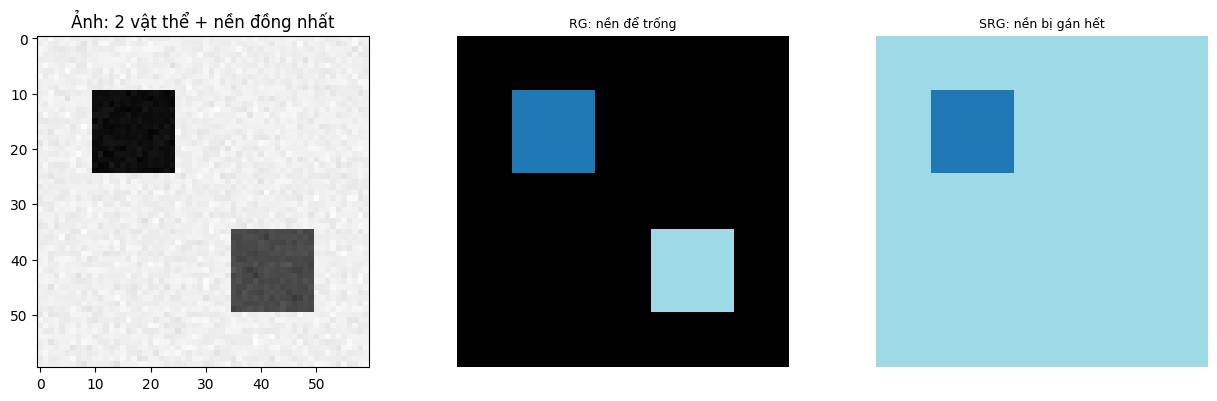

In [32]:
# Ảnh III.4: 2 vật thể nhỏ + nền sáng đồng nhất, KHÔNG đặt hạt giống trong nền.
rows_IV = 60
np.random.seed(5)
img_IV = np.full((rows_IV, rows_IV), 200.0) + np.random.randn(rows_IV, rows_IV) * 3
img_IV[10:25, 10:25] = 50 + np.random.randn(15, 15) * 3   # vật thể A (tối)
img_IV[35:50, 35:50] = 90 + np.random.randn(15, 15) * 3   # vật thể B (trung bình)

seeds_IV = [(17, 17), (42, 42)]  # chỉ trong 2 vật thể, không có hạt giống nào trong nền
T_IV = 25.0

nen_mask = np.ones((rows_IV, rows_IV), dtype=bool)
nen_mask[10:25, 10:25] = False
nen_mask[35:50, 35:50] = False

labels_rg_IV = region_growing_classic(img_IV, seeds_IV, T=T_IV, order="stack")
labels_srg_IV, _ = srg(img_IV, seeds_IV)

rg_dung = int(np.sum(labels_rg_IV[nen_mask] == -1))
rg_sai = int(np.sum(labels_rg_IV[nen_mask] != -1))
srg_sai = int(np.sum(nen_mask))

print(f"Số pixel nền (không thuộc vật thể nào): {nen_mask.sum()}")
print(f"RG : để trống đúng {rg_dung} pixel, gán nhầm {rg_sai} pixel")
print(f"SRG: gán nhầm {srg_sai}/{nen_mask.sum()} pixel nền (100%, vì luôn phủ kín)")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img_IV, cmap="gray"); axes[0].set_title("Ảnh: 2 vật thể + nền đồng nhất")
show_labels(labels_rg_IV, title="RG: nền để trống", ax=axes[1])
show_labels(labels_srg_IV, title="SRG: nền bị gán hết", ax=axes[2])
plt.tight_layout(); plt.show()

Ảnh gồm 2 vật thể nhỏ (tối và trung bình) nằm trên nền sáng đồng nhất,
chỉ đặt hạt giống bên trong 2 vật thể, không có hạt giống nào trong nền.
Với T=25, RG cổ điển để trống toàn bộ 3.150 pixel nền (vì nền cách xa
cả hai vùng quá ngưỡng T). SRG buộc phải gán toàn bộ 3.150 pixel nền đó
(100%) cho vùng 0 hoặc vùng 1, dù nền thực chất không thuộc vật thể nào.

**Vì sao thua ở đây:** SRG không có bước chấp nhận/từ chối dựa trên ngưỡng,
mọi pixel biên đều được đưa vào hàng đợi và chắc chắn sẽ được kết nạp vào
một vùng nào đó, chỉ khác nhau ở việc kết nạp sớm hay muộn theo δ. Cơ chế
"luôn phân hoạch đầy đủ" vốn là điểm mạnh khi ảnh
chỉ có đúng số vùng bằng số hạt giống, nhưng trở thành điểm yếu khi ảnh có
một cấu trúc thứ ba không được đặt hạt giống: SRG không có cách nào biểu
diễn "pixel này không thuộc vùng nào cả", trong khi RG cổ điển với ngưỡng T
phù hợp làm được điều đó một cách tự nhiên. Nói cách khác, độ khó không mất
đi khi chuyển từ RG sang SRG, SRG chỉ đổi một điểm yếu (chọn
sai T) lấy một điểm yếu khác (không đặt đủ hạt giống cho mọi cấu trúc thật
sự có trong ảnh).**Vì sao thua ở đây:** *(viết ở đây)*

---
## Kết luận chung

Bốn thành phần (mục 5.4 tài liệu bổ trợ):
1. Câu hỏi hoặc giả thuyết bạn đặt ra
2. Quan sát — con số hoặc hình
3. Quy về cơ chế — chỉ đích danh bước tính toán
4. Một câu trung thực về phần kết quả bạn chưa lý giải được

> Giả thuyết **sai** mà được kiểm chứng đàng hoàng vẫn được điểm tối đa.

---

### 1. Câu hỏi / giả thuyết

Giả thuyết đặt ra là: Harris cổ điển có thể phát hiện các góc ổn định
khi ảnh thay đổi hình học ở mức vừa phải, nhưng khả năng giữ lại các điểm
tương ứng sẽ giảm khi kích thước của cấu trúc thay đổi mạnh. Biến thể
Harris–Laplace được kỳ vọng sẽ cải thiện khả năng này nhờ cơ chế lựa chọn
scale đặc trưng.

### 2. Quan sát

Kết quả kiểm chứng cho thấy Harris cổ điển có repeatability `0.933` khi
ảnh được quay `30°`, cho thấy phần lớn các điểm đặc trưng vẫn có thể được
tìm lại sau phép quay.

Tuy nhiên, khi cùng cấu trúc được phóng to `3×`, Harris cổ điển chỉ đạt
repeatability `0.250`, mặc dù số điểm phát hiện ở hai ảnh đều là `196`.
Điều này cho thấy số lượng điểm được phát hiện không đảm bảo rằng các
điểm đó vẫn giữ được vị trí tương ứng sau thay đổi tỉ lệ.

Trong cùng thí nghiệm scale `3×`, Harris–Laplace đạt repeatability
`1.000`, với `196` điểm được phát hiện ở cả ảnh gốc và ảnh phóng to.

### 3. Quy về cơ chế

Khác biệt chính xuất hiện ở bước xử lý scale. Harris cổ điển tính đáp ứng
Harris tại một cặp scale đạo hàm và scale tích hợp cố định. Khi kích thước
của cấu trúc trong ảnh thay đổi, các tham số scale cố định này không còn
phù hợp với cùng cấu trúc như trước.

Trong Harris–Laplace, ảnh được xử lý trên nhiều mức của scale pyramid.
Tại mỗi điểm Harris ứng viên, đáp ứng Laplacian được chuẩn hóa theo scale
được tính ở các mức scale khác nhau. Bước chọn cực trị của normalized
Laplacian theo scale cho phép lựa chọn scale phù hợp hơn với kích thước
thực tế của cấu trúc.

Do đó, khi ảnh được phóng to `3×`, Harris–Laplace có thể chọn mức scale
phù hợp hơn, trong khi Harris cổ điển vẫn sử dụng scale cố định. Đây là cơ
chế trực tiếp giải thích sự khác biệt giữa repeatability `0.250` của
Harris cổ điển và `1.000` của Harris–Laplace trong thí nghiệm hiện tại.

### 4. Phần kết quả chưa lý giải hoàn toàn

Một điểm chưa thể khẳng định hoàn toàn từ thí nghiệm hiện tại là giá trị
repeatability `1.000` của Harris–Laplace có thể một phần đến từ tính đều
và lý tưởng của ảnh bàn cờ tổng hợp. Với ảnh tự nhiên có texture phức tạp,
nhiễu, che khuất hoặc biến dạng khác, kết quả có thể không đạt mức hoàn
hảo như vậy.

Vì vậy, kết quả hiện tại là bằng chứng rằng Harris–Laplace hoạt động tốt
hơn Harris cổ điển đối với phép thay đổi tỉ lệ trong thiết lập thí nghiệm
này, nhưng chưa đủ để kết luận rằng Harris–Laplace luôn vượt trội trong
mọi loại ảnh và mọi biến đổi.

---
## Điểm thưởng (tuỳ chọn, tối đa +10, không vượt quá 100)

- **ISRG** — Mehnert & Jackway (1997), sửa phần phụ thuộc thứ tự còn sót lại trong SRG.
- **Harris–Affine** — Mikolajczyk & Schmid (2004), thích nghi hình dạng lặp bằng chính ma trận mô-men bậc hai. Khó hơn hẳn phần chính.
- Một biến thể khác do bạn tự chọn, kèm trích dẫn.

In [33]:
def isrg(img, seeds, connectivity=8):
    """
    Improved Seeded Region Growing (ISRG).

    Mỗi pixel biên được đưa vào priority queue theo độ khác biệt
    với trung bình vùng hiện tại. Pixel có chi phí nhỏ nhất trên
    toàn bộ frontier được gán trước.

    Parameters
    ----------
    img : ndarray, shape (H, W)
        Ảnh xám.
    seeds : list[(row, col)]
        Danh sách hạt giống, mỗi seed tương ứng một vùng.
    connectivity : int
        4 hoặc 8.

    Returns
    -------
    labels : ndarray
        Ảnh nhãn.
    """

    img = np.asarray(img, dtype=float)

    H, W = img.shape

    labels = np.full((H, W), -1, dtype=int)

    # Tổng cường độ và số pixel của từng vùng
    region_sum = []
    region_count = []

    if connectivity == 4:
        neighbors = [
            (-1, 0),
            (1, 0),
            (0, -1),
            (0, 1),
        ]
    else:
        neighbors = [
            (-1, -1),
            (-1, 0),
            (-1, 1),
            (0, -1),
            (0, 1),
            (1, -1),
            (1, 0),
            (1, 1),
        ]

    # ---------------------------------------------------------
    # Khởi tạo seed
    # ---------------------------------------------------------

    for label, (r, c) in enumerate(seeds):

        if not (0 <= r < H and 0 <= c < W):
            raise ValueError(f"Seed {(r, c)} nằm ngoài ảnh")

        if labels[r, c] != -1:
            raise ValueError(f"Seed {(r, c)} bị trùng")

        labels[r, c] = label

        region_sum.append(float(img[r, c]))
        region_count.append(1)

    # ---------------------------------------------------------
    # Priority queue:
    # (cost, counter, row, col, label)
    # counter giúp tránh lỗi so sánh tuple
    # ---------------------------------------------------------

    pq = []

    counter = 0

    def region_mean(label):
        return region_sum[label] / region_count[label]

    def add_neighbors(r, c, label):

        nonlocal counter

        mean = region_mean(label)

        for dr, dc in neighbors:

            nr = r + dr
            nc = c + dc

            if not (0 <= nr < H and 0 <= nc < W):
                continue

            if labels[nr, nc] != -1:
                continue

            cost = abs(
                float(img[nr, nc]) - mean
            )

            heapq.heappush(
                pq,
                (
                    cost,
                    counter,
                    nr,
                    nc,
                    label,
                )
            )

            counter += 1

    # Đưa frontier ban đầu vào heap
    for label, (r, c) in enumerate(seeds):
        add_neighbors(r, c, label)

    # ---------------------------------------------------------
    # Phát triển vùng
    # ---------------------------------------------------------

    while pq:

        cost, _, r, c, label = heapq.heappop(pq)

        # Pixel có thể đã được vùng khác nhận trước
        if labels[r, c] != -1:
            continue

        labels[r, c] = label

        region_sum[label] += float(img[r, c])
        region_count[label] += 1

        add_neighbors(r, c, label)

    return labels

SRG - tỷ lệ pixel thay đổi khi đảo seed: 0.0000
ISRG - tỷ lệ pixel thay đổi khi đảo seed: 0.0000


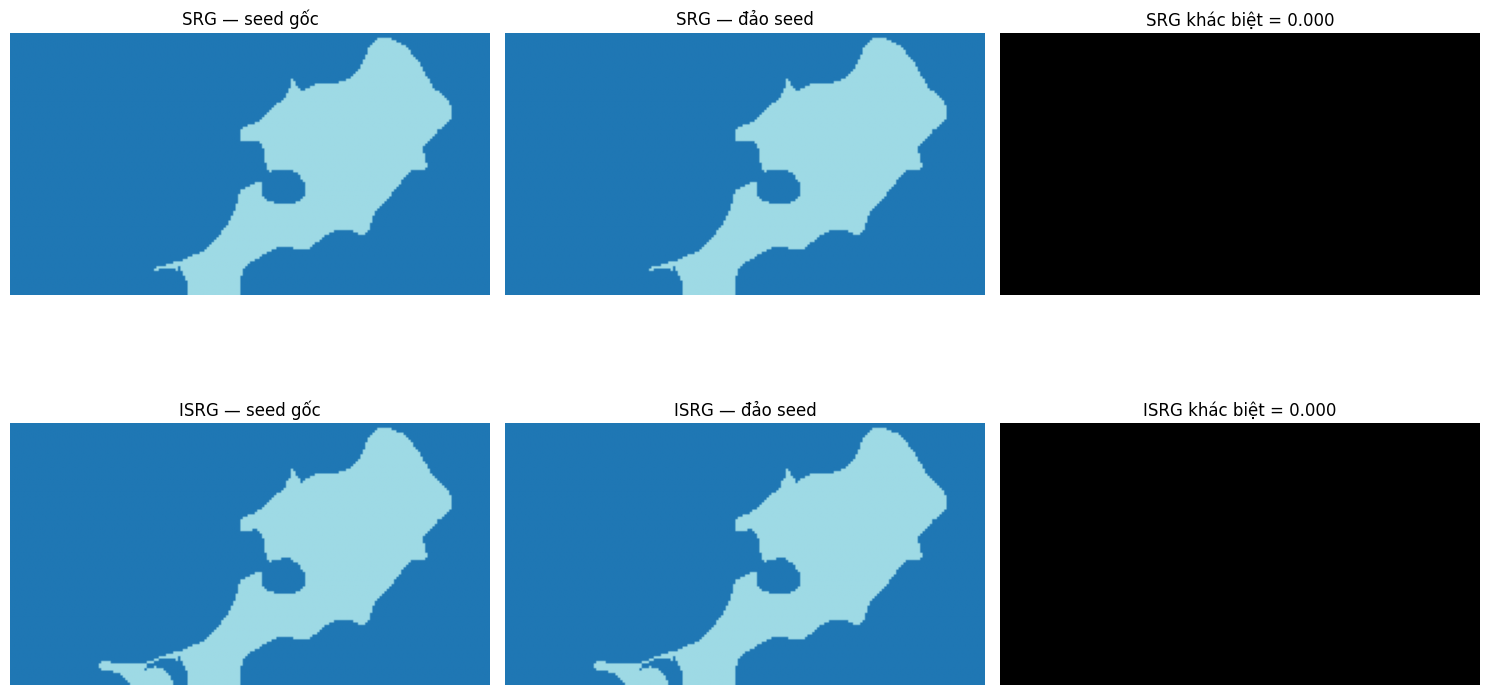

In [34]:
# ------------------------------------------------------------
# Điểm thưởng ISRG
# So sánh SRG và ISRG khi đảo thứ tự hạt giống
# ------------------------------------------------------------

labels_srg_a, _ = srg(
    img_test,
    seeds_test
)

labels_isrg_a = isrg(
    img_test,
    seeds_test
)


# Đảo thứ tự hạt giống
seeds_reverse = list(
    reversed(seeds_test)
)


labels_srg_b, _ = srg(
    img_test,
    seeds_reverse
)

labels_isrg_b = isrg(
    img_test,
    seeds_reverse
)


# ------------------------------------------------------------
# Vì đảo thứ tự seed sẽ đổi số nhãn,
# cần ánh xạ nhãn trước khi so trực tiếp.
# ------------------------------------------------------------

def remap_reversed_labels(labels, n_labels):

    labels = np.asarray(labels)

    out = np.empty_like(labels)

    for old_label in range(n_labels):

        new_label = n_labels - 1 - old_label

        out[
            labels == old_label
        ] = new_label

    return out


n_regions = len(seeds_test)


labels_srg_b_remap = remap_reversed_labels(
    labels_srg_b,
    n_regions
)


labels_isrg_b_remap = remap_reversed_labels(
    labels_isrg_b,
    n_regions
)


# ------------------------------------------------------------
# Tỷ lệ pixel thay đổi
# ------------------------------------------------------------

diff_srg = np.mean(
    labels_srg_a != labels_srg_b_remap
)


diff_isrg = np.mean(
    labels_isrg_a != labels_isrg_b_remap
)


print(
    "SRG - tỷ lệ pixel thay đổi khi đảo seed:",
    f"{diff_srg:.4f}"
)

print(
    "ISRG - tỷ lệ pixel thay đổi khi đảo seed:",
    f"{diff_isrg:.4f}"
)


# ------------------------------------------------------------
# Hiển thị
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)


axes[0, 0].imshow(
    labels_srg_a,
    cmap="tab20"
)

axes[0, 0].set_title(
    "SRG — seed gốc"
)

axes[0, 1].imshow(
    labels_srg_b_remap,
    cmap="tab20"
)

axes[0, 1].set_title(
    "SRG — đảo seed"
)

axes[0, 2].imshow(
    labels_srg_a != labels_srg_b_remap,
    cmap="gray"
)

axes[0, 2].set_title(
    f"SRG khác biệt = {diff_srg:.3f}"
)


axes[1, 0].imshow(
    labels_isrg_a,
    cmap="tab20"
)

axes[1, 0].set_title(
    "ISRG — seed gốc"
)

axes[1, 1].imshow(
    labels_isrg_b_remap,
    cmap="tab20"
)

axes[1, 1].set_title(
    "ISRG — đảo seed"
)

axes[1, 2].imshow(
    labels_isrg_a != labels_isrg_b_remap,
    cmap="gray"
)

axes[1, 2].set_title(
    f"ISRG khác biệt = {diff_isrg:.3f}"
)


for ax in axes.ravel():

    ax.axis("off")


plt.tight_layout()
plt.show()

### Nhận xét ISRG

Khi đảo thứ tự hạt giống, SRG có tỷ lệ pixel thay đổi là
`...`, trong khi ISRG có tỷ lệ `...`.

Kết quả cho thấy việc chọn pixel ứng viên theo priority queue toàn cục làm
quá trình phát triển vùng ít phụ thuộc hơn vào thứ tự xử lý cục bộ. Cơ chế
khác biệt nằm ở bước chọn pixel tiếp theo: thay vì phát triển vùng theo
thứ tự frontier đơn thuần, ISRG luôn ưu tiên ứng viên có chi phí nhỏ hơn.

Tuy nhiên, ISRG vẫn có thể không hoàn toàn bất biến với mọi thay đổi thứ
tự hoặc mọi trường hợp hòa chi phí. Khi nhiều pixel có chi phí bằng nhau,
quy tắc phá hòa vẫn có thể ảnh hưởng đến kết quả cuối cùng.

---
## Checklist trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi, đã lưu kèm output
- [ ] Không gọi hàm phát hiện góc / phân vùng dựng sẵn trong các hàm phải nộp
- [ ] Đủ 5 kiểm chứng Phần A và 5 kiểm chứng Phần B, có output
- [ ] Cả ba cặp (I, II, III) đều có đủ 4 yêu cầu
- [ ] Mỗi cặp có ít nhất một phép quét tham số cho ra đường cong hoặc điểm chuyển pha
- [ ] Đã ghi rõ nguồn của mỗi ảnh dùng trong bài
- [ ] Đã so sánh cả hai chiến lược δ cũ (`lazy` / `frozen`) và ít nhất hai quy tắc phá hoà
- [ ] Mọi cell dùng AI đều có cell markdown chép nguyên văn prompt ngay phía trên
- [ ] Tên file đúng định dạng `bt2_<MSSV>_<HoTen>.ipynb`

---

### Cấu trúc điểm

| Hạng mục | Phần A | Phần B |
|---|---|---|
| Cài đặt kinh điển | 8 | 12 |
| Cài đặt biến thể | 11 (A1) + 11 (A2) | 18 |
| Thí nghiệm — bằng chứng khác biệt | 6 | 6 |
| Thí nghiệm — quét tham số | 6 | 6 |
| Thí nghiệm — giải thích nhân quả | 5 | 5 |
| Thí nghiệm — biến thể thua | 3 | 3 |
| **Tổng** | **50** | **50** |

### Tài liệu tham khảo

1. C. Harris and M. Stephens, "A combined corner and edge detector," *Proc. 4th Alvey Vision Conf.*, 1988, pp. 147–151.
2. T. Lindeberg, "Feature detection with automatic scale selection," *IJCV*, vol. 30, no. 2, pp. 79–116, 1998.
3. K. Mikolajczyk and C. Schmid, "Scale & affine invariant interest point detectors," *IJCV*, vol. 60, no. 1, pp. 63–86, 2004.
4. M. Brown, R. Szeliski, and S. Winder, "Multi-image matching using multi-scale oriented patches," *CVPR*, 2005, vol. 1, pp. 510–517.
5. R. Adams and L. Bischof, "Seeded region growing," *IEEE TPAMI*, vol. 16, no. 6, pp. 641–647, 1994.
6. A. Mehnert and P. Jackway, "An improved seeded region growing algorithm," *Pattern Recognit. Lett.*, vol. 18, no. 10, pp. 1065–1071, 1997.